**CSI 4106 Introduction to Artificial Intelligence** <br/>
*Assignment 3: Neural Networks*

# Identification

Name: Shabrina Sharmin<br/>
Student Number: 300230297

## 1. Exploratory Analysis

### Loading the dataset

A custom dataset has been created for this assignment. It has been made available on a public GitHub repository:

- [github.com/turcotte/csi4106-f24/tree/main/assignments-data/a3](https://github.com/turcotte/csi4106-f24/tree/main/assignments-data/a3)

Access and read the dataset directly from this GitHub repository in your Jupyter notebook.

You can use this code cell for you import statements and other initializations.

In [5]:
# Code cell
import pandas as pd
#Setting the url to point to the raw dataset file
url_test = 'https://raw.githubusercontent.com/turcotte/csi4106-f24/refs/heads/main/assignments-data/a3/cb513_test.csv'
url_train = 'https://raw.githubusercontent.com/turcotte/csi4106-f24/refs/heads/main/assignments-data/a3/cb513_train.csv'
url_validation = 'https://raw.githubusercontent.com/turcotte/csi4106-f24/refs/heads/main/assignments-data/a3/cb513_valid.csv'
#load the 3 data sets
protien_df_test = pd.read_csv(url_test)
protien_df_train = pd.read_csv(url_train)
protien_df_validation = pd.read_csv(url_validation)
print('test')
print(protien_df_test.head())
print('train')
print(protien_df_train.head())
print('validation')
print(protien_df_validation.head())

test
   2       0  0.1     0.2     0.3     0.4     0.6     0.7     0.8  0.9  ...  \
0  1  0.1111  0.0  0.0000  0.0000  0.2222  0.1111  0.0000  0.0000  0.0  ...   
1  1  0.3750  0.0  0.0625  0.0000  0.0312  0.0312  0.0625  0.0312  0.0  ...   
2  1  0.4516  0.0  0.0000  0.0000  0.0000  0.2742  0.0000  0.0806  0.0  ...   
3  0  0.0000  0.0  0.0625  0.0312  0.0000  0.7500  0.0000  0.0000  0.0  ...   
4  2  0.0000  0.0  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0  ...   

    0.409   0.410   0.411  0.375.3   0.412   0.413  0.414  0.415   0.416  \
0  0.0000  0.0000  0.0000   0.0000  0.0000  1.0000    0.0    0.0  0.0000   
1  0.0312  0.0312  0.0312   0.0312  0.0000  0.0625    0.0    0.0  0.0000   
2  0.0000  0.0000  0.0000   0.0000  0.0000  0.0000    0.0    0.0  0.0161   
3  0.0938  0.0000  0.1562   0.1250  0.0000  0.0312    0.0    0.0  0.0000   
4  0.1333  0.1333  0.1333   0.0000  0.0667  0.0667    0.0    0.0  0.0000   

   0.417  
0    0.0  
1    0.0  
2    0.0  
3    0.0  
4    0.0

### Data Pre-Processing

2. **Shuffling the Rows**:

    - Since examples are generated by sliding a window across each protein sequence, most adjacent examples originate from the same protein and share 20 positions. To mitigate the potential negative impact on model training, the initial step involves shuffling the **rows** of the data matrix.

In [6]:
# Code cell
# suffle the test set
protien_df_test = protien_df_test.sample(frac=1, random_state=42)
print('Suffle test')
print(protien_df_test.head())

# suffle the train set
protien_df_train = protien_df_train.sample(frac=1, random_state=42)
print('Suffle train')
print(protien_df_train.head())

#suffle the validation set
protien_df_validation = protien_df_validation.sample(frac=1, random_state=42)
print('Suffle validation')
print(protien_df_validation.head())

Suffle test
      2       0     0.1     0.2     0.3    0.4     0.6     0.7     0.8  \
625   0  0.2143  0.3571  0.0000  0.0000  0.000  0.0000  0.0000  0.1429   
7029  0  0.0103  0.0000  0.0000  0.0000  0.299  0.0000  0.0000  0.3196   
101   1  0.0000  0.0000  0.0408  0.0340  0.000  0.7959  0.0000  0.0000   
3956  2  0.3333  0.3333  0.0000  0.0000  0.000  0.0000  0.0000  0.0000   
2018  0  0.0544  0.0000  0.0068  0.0544  0.000  0.0068  0.0068  0.0068   

         0.9  ...   0.409   0.410   0.411  0.375.3   0.412   0.413   0.414  \
625   0.0000  ...  0.0000  0.0000  0.0000   0.0000  0.0000  0.0000  0.0000   
7029  0.0103  ...  0.7526  0.0000  0.0103   0.0412  0.0103  0.0206  0.0000   
101   0.0408  ...  0.0000  0.0000  0.0136   0.0000  0.0000  0.0068  0.0000   
3956  0.0000  ...  0.0000  0.0000  0.0000   0.0000  0.0000  0.0000  0.0000   
2018  0.3469  ...  0.0000  0.0068  0.0068   0.0000  0.0068  0.1837  0.0068   

       0.415   0.416  0.417  
625   0.0000  0.5714    0.0  
7029  0.0000  

3. **Scaling of Numerical Features**:

    - Since all 462 features are proportions represented as values between 0 and 1, scaling may not be necessary. In our evaluations, using [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) actually degraded model performance. Within your pipeline, compare the effects of not scaling the data versus applying [MinMaxScaler](https://scikit-learn.org/1.5/modules/generated/sklearn.preprocessing.MinMaxScaler.html). In the interest of time, a single experiment will suffice. It is important to note that when scaling is applied, a uniform method should be used across all columns, given their homogeneous nature.

In [7]:
## Code cell
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

#separate the target(y) and features(x) from training set
X_train = protien_df_train.drop(protien_df_train.columns[0], axis=1)
y_train = protien_df_train[protien_df_train.columns[0]]
# print('X_train')
# print(X_train.head())
# print('y_train')
# print(y_train.head())

#separate the target(y) and features(x) from test set
X_test = protien_df_test.drop(protien_df_test.columns[0], axis=1)
y_test = protien_df_test[protien_df_test.columns[0]]

##problem
# Ensure that X_train and X_test have the same column names
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

#no scaling
# model training with no scaling of the features
model_LR_no_scaling = LogisticRegression(max_iter=1000)
model_LR_no_scaling.fit(X_train, y_train)
y_pred_no_scaling = model_LR_no_scaling.predict(X_test)
accuracy_no_scaling = accuracy_score(y_test, y_pred_no_scaling)


# MinMax scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# model training with MinMax scaling
model_LR_scaled = LogisticRegression(max_iter=1000)
model_LR_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = model_LR_scaled.predict(X_test_scaled)
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)

# diff of accuracy
print("Accuracy with no scaling:", accuracy_no_scaling)
print("Accuracy with MinMax scaling:", accuracy_scaled)







Accuracy with no scaling: 0.3676490378145606
Accuracy with MinMax scaling: 0.3548647557529269


4. **Isolating the Target and the Data**:

    - In the CSV files, the target and data are combined. To prepare for our machine learning experiments, separate the training data $X$ and the target vector $y$ for each of the three datasets.

In [9]:
# Code cell
# The features and target values for traing and test set has been separated above code section
#separate target values and features for validation set
X_validation = protien_df_validation.drop(protien_df_validation.columns[0], axis=1)
y_validation = protien_df_validation[protien_df_validation.columns[0]]

### Model Development & Evaluation

5. **Model Development**:

    - **Dummy Model**: Implement a model utilizing the [DummyClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html). This model disregards the input data and predicts the majority class. Such model is sometimes called a straw man model.

    - **Basline Model**: As a baseline model, select one of the previously studied machine learning algorithms: Decision Trees, K-Nearest Neighbors (KNN), or Logistic Regression. Use the default parameters provided by scikit-learn to train each model as a baseline. Why did you choose this particular classifier? Why do you think it should be appropriate for this specific task?

    - **Neural Network Model**: Utilizing [Keras](https://keras.io) and [TensorFlow](https://www.tensorflow.org), construct a sequential model comprising an input layer, a hidden layer, and an output layer. The input layer should consist of 462 nodes, reflecting the 462 attributes of each example. The hidden layer should include 8 nodes and employ the default activation function. The output layer should contain three nodes, corresponding to the three classes: helix (0), sheet (1), and coil (2). Apply the softmax activation function to the output layer to ensure that the outputs are treated as probabilities, with their sum equaling 1 for each training example.

    We therefore have three models: dummy, baseline, and neural network.

In [10]:
# Code cell
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
import tensorflow as tf




#Dummy model
dummy_model = DummyClassifier(strategy='most_frequent')
dummy_model.fit(X_train, y_train)
y_pred_dummy = dummy_model.predict(X_test)



#BaseLine model(Logistic regression)
logistic_model = LogisticRegression()
logistic_model.fit(X_train, y_train)
y_pred_logistic = logistic_model.predict(X_test)

# Neural network
neural_model = tf.keras.Sequential()
# input layer with 462 nurons which is connected with hidden layer with 8 nodes
neural_model.add(tf.keras.layers.Dense(8, input_dim=462, activation='relu'))
#output layer with 3 nodes and 'softmoc as activation func
neural_model.add(tf.keras.layers.Dense(3, activation='softmax'))
neural_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
neural_model.summary()
neural_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_validation, y_validation))
y_pred_neural = neural_model.predict(X_test)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                      │ (None, 8)                   │           3,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,731 (14.57 KB)

 Trainable params: 3,731 (14.57 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5925 - loss: 0.8935 - val_accuracy: 0.6701 - val_loss: 0.7678
Epoch 2/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6900 - loss: 0.7383 - val_accuracy: 0.6745 - val_loss: 0.7652
Epoch 3/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6939 - loss: 0.7295 - val_accuracy: 0.6679 - val_loss: 0.7653
Epoch 4/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6955 - loss: 0.7262 - val_accuracy: 0.6683 - val_loss: 0.7612
Epoch 5/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6955 - loss: 0.7229 - val_accuracy: 0.6754 - val_loss: 0.7558
Epoch 6/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7000 - loss: 0.7129 - val_accuracy: 0.6845 - val_loss: 0.7483
Epoch 7/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7036 - loss: 0.7062 - val_accuracy: 0.6868 - val_loss: 0.7428
Epoch 8/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7070 - loss: 0.6995 - 

6. **Model Evaluation**:

    - Employ cross-validation to assess the performance of the baseline model. Select a small number of folds to prevent excessive computational demands.

In [11]:
# Code cell
from sklearn.model_selection import cross_validate
import numpy as np
from sklearn.model_selection import KFold
#cross validation for baseline model (Decision tree)
scoring = ['precision_macro', 'recall_macro','f1_macro']
#cross validation ensuring suffling
cvKF = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_baseline_model = cross_validate(baseline_model, X_train, y_train, cv=cvKF, scoring=scoring)
print('\n### Test results metric for Cross Validation for Baseline model (Decision tree) ###')
print("Precision:", np.mean(cv_scores_baseline_model['test_precision_macro']))
print("Recall:", np.mean(cv_scores_baseline_model['test_recall_macro']))
print("F1 Score:", np.mean(cv_scores_baseline_model['test_f1_macro']))

#baseline model (Logistic Regression)
cv_scores_logistic_model = cross_validate(logistic_model, X_train, y_train, cv=cvKF, scoring=scoring)
print('\n### Test results metric for Cross Validation for Baseline model (Logistic Regression) ###')
print("Precision:", np.mean(cv_scores_logistic_model['test_precision_macro']))
print("Recall:", np.mean(cv_scores_logistic_model['test_recall_macro']))
print("F1 Score:", np.mean(cv_scores_logistic_model['test_f1_macro']))



### Test results metric for Cross Validation for Baseline model (Decision tree) ###
Precision: 0.48050536025310253
Recall: 0.4806990661794795
F1 Score: 0.4805723193468959

### Test results metric for Cross Validation for Baseline model (Logistic Regression) ###
Precision: 0.6782868800791191
Recall: 0.6602323822153763
F1 Score: 0.66627309892267


    - **Training neural networks can be time-consuming.** Consequently, their performance is typically assessed once using a validation set. Make sure to not use the test set until the very end of the assignment.

In [12]:
# Code cell
!pip install scikeras
import tensorflow as tf
#from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from scikeras.wrappers import KerasClassifier

#cross validation for neural network
cvKF = KFold(n_splits=2, shuffle=True, random_state=42)
#keras model that has been used for neural model is not compatiblKerasClassifiere with cross vaidate as it expexts scikit estimator
neural_model_wrapped = KerasClassifier(build_fn=neural_model, epochs=5, batch_size=32, verbose=0)
cv_scores_neural_model = cross_validate(neural_model_wrapped, X_train, y_train, cv=cvKF, scoring=scoring)

print('\n### Test results metric for Cross Validation for neural model ###')
#print("Score: ", dt_cv_scores)
print("Precision:", np.mean(cv_scores_neural_model['test_precision_macro']))
print("Recall:", np.mean(cv_scores_neural_model['test_recall_macro']))
print("F1 Score:", np.mean(cv_scores_neural_model['test_f1_macro']))

/usr/local/lib/python3.10/dist-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/usr/local/lib/python3.10/dist-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)



### Test results metric for Cross Validation for neural model ###
Precision: 0.6981517214686501
Recall: 0.6806840152244549
F1 Score: 0.6869207294585653


    - Assess the models using metrics such as precision, recall, and F1-score.

### Hyperparameter Optimization

7. **Baseline Model:**

    - To ensure a fair comparison for our baseline model, we will examine how varying hyperparameter values affect its performance. This prevents the erroneous conclusion that neural networks inherently perform better, when in fact, appropriate hyperparameter tuning could enhance the baseline model's performance.

    - Focus on the following relevant hyperparameters for each model:

        - [DecisionTreeClassifier](https://scikit-learn.org/dev/modules/generated/sklearn.tree.DecisionTreeClassifier.html): `criterion` and `max_depth`.
  
        - [LogisticRegression](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LogisticRegression.html): `penalty`, `max_iter`, and `tol`.
  
        - [KNeighborsClassifier](https://scikit-learn.org/dev/modules/generated/sklearn.neighbors.KNeighborsClassifier.html): `n_neighbors` and `weights`.

    - Employ a grid search strategy or utilize scikit-learn's built-in methods [GridSearchCV](https://scikit-learn.org/dev/modules/generated/sklearn.model_selection.GridSearchCV.html) to thoroughly evaluate all combinations of hyperparameter values. Cross-validation should be used to assess each combination.

    - Quantify the performance of each hyperparameter configuration using precision, recall, and F1-score as metrics.

    - Analyze the findings and offer insights into which hyperparameter configurations achieved optimal performance for each model.

In [13]:
# Code cell
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

#Hyperparameter optimization for Baseline (Logistic Regression)
print('\n### Experiment results  for Logistic Grid Search  ###')
logistic_model_params= {
    'penalty': ['l2'],
    #'solver' : ['lbfgs','newton-cg', 'liblinear', 'sag', 'saga'],
    'max_iter': [100, 200, 400, 800, 1600],
    'tol' : [0.01, 0.001, 0.0001]
}
Logistic_grid_base_model = LogisticRegression()
Logistic_grid_search_base_model = GridSearchCV(Logistic_grid_base_model, logistic_model_params, cv=5, return_train_score=True, scoring=scoring, refit='f1_macro')
Logistic_grid_search_base_model.fit(X_train, y_train)
print(Logistic_grid_search_base_model.best_params_, Logistic_grid_search_base_model.best_score_)





### Experiment results  for Logistic Grid Search  ###


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


{'max_iter': 100, 'penalty': 'l2', 'tol': 0.0001} 0.6666087768284437


8. **Neural Network:**

    In our exploration and tuning of neural networks, we focus on the following hyperparameters:

    - **Single hidden layer, varying the number of nodes**.

        - Start with a single node in the hidden layer. Use a graph to depict the progression of loss and accuracy for both the training and validation sets, with the horizontal axis representing the number of training epochs and the vertical axis showing loss and accuracy. Training this network should be relatively fast, so let's conduct training for 50 epochs. Observing the graph, what do you conclude? Is the network underfitting or overfitting? Why?

        - Repeat the above process using 2 and 4 nodes in the hidden layer. Use the same type of graph to document your observations regarding loss and accuracy.

        - Start with 8 nodes in the hidden layer and progressively double the number of nodes until it surpasses the number of nodes in the input layer. This results in seven experiments and corresponding graphs for the following configurations: 8, 16, 32, 64, 128, 256, and 512 nodes. Document your observations throughout the process.
        
        - Ensure that the **number of training epochs** is adequate for **observing an increase in validation loss**. **Tip**: During model development, start with a small number of epochs, such as 5 or 10. Once the model appears to perform well, test with larger values, like 40 or 80 epochs, which proved reasonable in our tests. Based on your observations, consider conducting further experiments, if needed. How many epochs were ultimately necessary?

In [14]:
import matplotlib.pyplot as plt
# function to plot graph
def plot_graph(history, message):
  #plots the loss and accuracy for training and validation set for a given history object
  #retrieve the num of epoch
  epochs = range(1,len(history.history['loss'])+1)
  plt.figure(figsize=(14,5))
  #plot loss
  plt.subplot(1,2,1)
  plt.plot(epochs, history.history['loss'], label='Training Loss')
  plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
  plt.title('Training and Validation Loss for' + message)
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
#plot accuracy
  plt.subplot(1,2,2)
  plt.plot(epochs, history.history['accuracy'], label='Training Accuracy')
  plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
  plt.title('Training and Validation Accuracy for ' + message)
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()
#adjust the layout and display plots
  plt.tight_layout()
  plt.show()




### Experiment results  for Neural network a hidden layer nodes = 2  ###


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                     │ (None, 2)                   │             926 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ (None, 3)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 935 (3.65 KB)

 Trainable params: 935 (3.65 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5431 - loss: 0.9594 - val_accuracy: 0.6577 - val_loss: 0.8002
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6828 - loss: 0.7581 - val_accuracy: 0.6745 - val_loss: 0.7763
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6887 - loss: 0.7427 - val_accuracy: 0.6704 - val_loss: 0.7718
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6924 - loss: 0.7360 - val_accuracy: 0.6666 - val_loss: 0.7746
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6910 - loss: 0.7385 - val_accuracy: 0.6704 - val_loss: 0.7698
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6924 - loss: 0.7360 - val_accuracy: 0.6702 - val_loss: 0.7685
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6909 - loss: 0.7411 - val_accuracy: 0.6739 - val_loss: 0.7690
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.6924 - loss: 0.7330 -

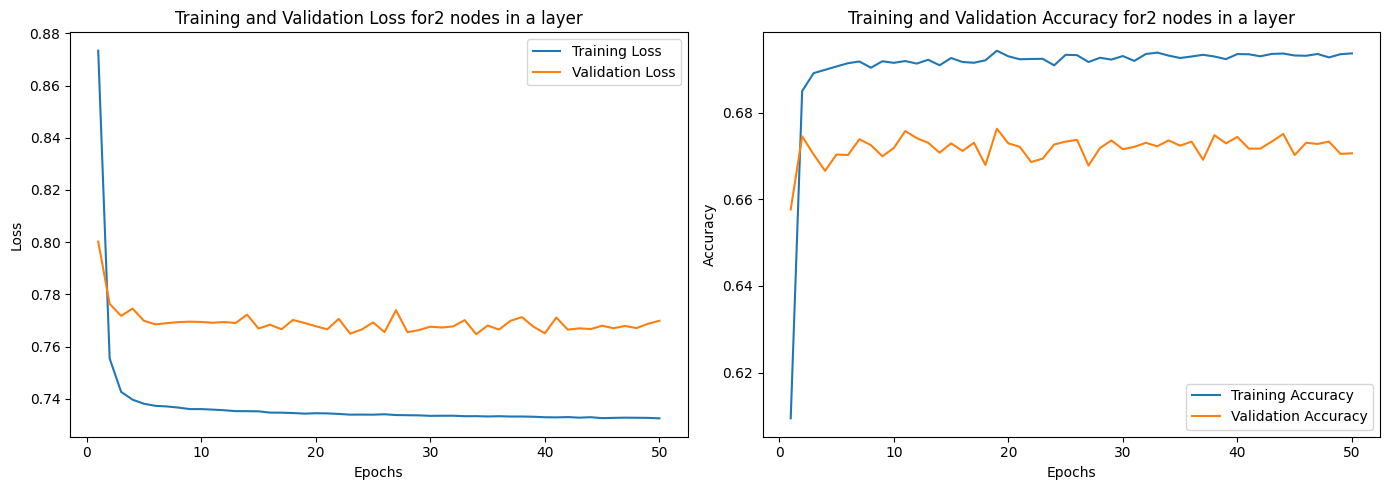

233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

### Experiment results  for Neural network Hidden layer nodes = 4  ###


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_34 (Dense)                     │ (None, 4)                   │           1,852 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_35 (Dense)                     │ (None, 3)                   │              15 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,867 (7.29 KB)

 Trainable params: 1,867 (7.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5378 - loss: 0.9466 - val_accuracy: 0.6748 - val_loss: 0.7732
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6864 - loss: 0.7451 - val_accuracy: 0.6709 - val_loss: 0.7674
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6911 - loss: 0.7368 - val_accuracy: 0.6658 - val_loss: 0.7720
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6907 - loss: 0.7373 - val_accuracy: 0.6704 - val_loss: 0.7689
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6921 - loss: 0.7341 - val_accuracy: 0.6627 - val_loss: 0.7723
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6918 - loss: 0.7356 - val_accuracy: 0.6744 - val_loss: 0.7667
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6907 - loss: 0.7317 - val_accuracy: 0.6774 - val_loss: 0.7641
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6953 - loss: 0.7268 - 

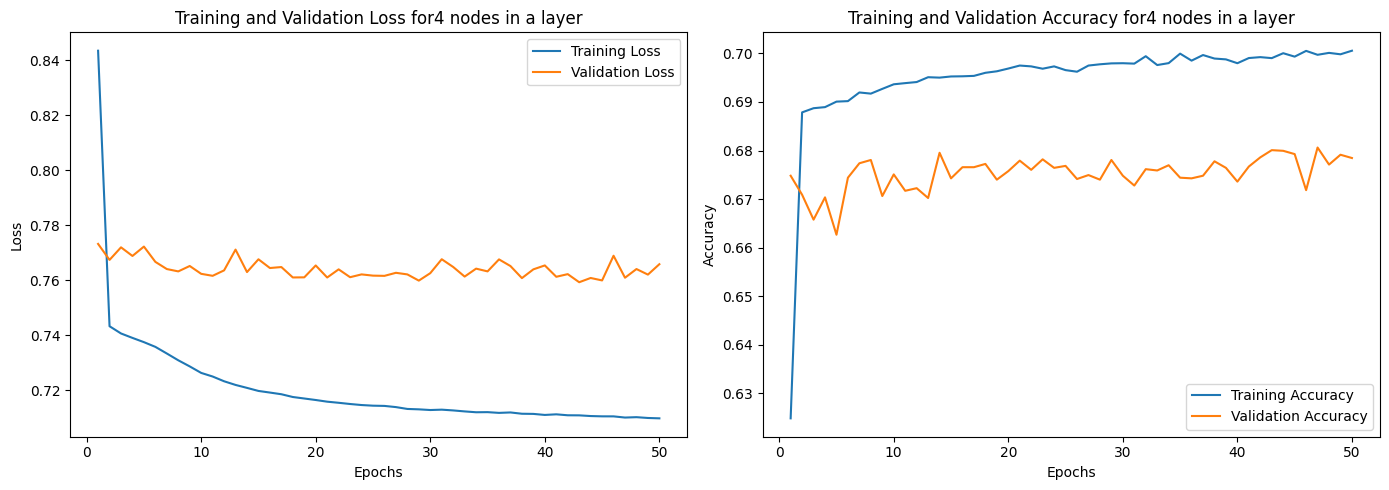

233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

### Experiment results  for Neural networl Hidden layer nodes = 8  ###


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                     │ (None, 8)                   │           3,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_37 (Dense)                     │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,731 (14.57 KB)

 Trainable params: 3,731 (14.57 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5888 - loss: 0.9057 - val_accuracy: 0.6694 - val_loss: 0.7703
Epoch 2/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6881 - loss: 0.7354 - val_accuracy: 0.6718 - val_loss: 0.7766
Epoch 3/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6920 - loss: 0.7293 - val_accuracy: 0.6760 - val_loss: 0.7574
Epoch 4/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6935 - loss: 0.7255 - val_accuracy: 0.6829 - val_loss: 0.7555
Epoch 5/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7008 - loss: 0.7080 - val_accuracy: 0.6832 - val_loss: 0.7455


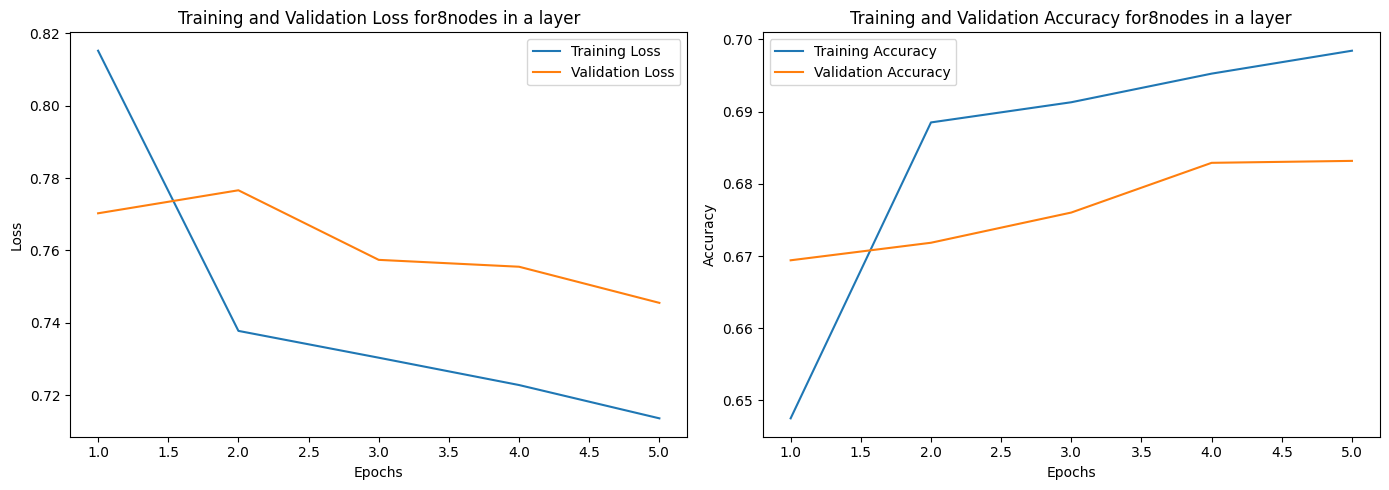

233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
### ------------------------------------------------------###

### Experiment results  for Neural networl Hidden layer nodes = 16  ###


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_38 (Dense)                     │ (None, 16)                  │           7,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_39 (Dense)                     │ (None, 3)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,459 (29.14 KB)

 Trainable params: 7,459 (29.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5913 - loss: 0.8849 - val_accuracy: 0.6671 - val_loss: 0.7710
Epoch 2/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6899 - loss: 0.7362 - val_accuracy: 0.6721 - val_loss: 0.7645
Epoch 3/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6946 - loss: 0.7226 - val_accuracy: 0.6791 - val_loss: 0.7548
Epoch 4/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6991 - loss: 0.7090 - val_accuracy: 0.6826 - val_loss: 0.7475
Epoch 5/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7141 - loss: 0.6866 - val_accuracy: 0.6875 - val_loss: 0.7368


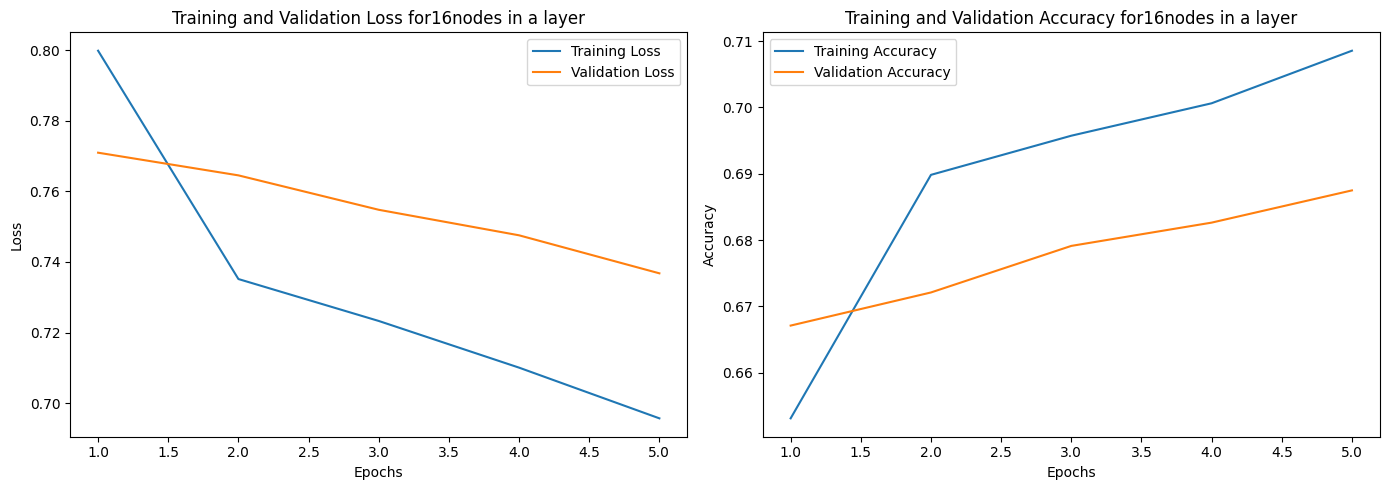

233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
### ------------------------------------------------------###

### Experiment results  for Neural networl Hidden layer nodes = 32  ###


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                     │ (None, 32)                  │          14,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_41 (Dense)                     │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,915 (58.26 KB)

 Trainable params: 14,915 (58.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6174 - loss: 0.8540 - val_accuracy: 0.6693 - val_loss: 0.7740
Epoch 2/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6899 - loss: 0.7340 - val_accuracy: 0.6799 - val_loss: 0.7576
Epoch 3/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7055 - loss: 0.7037 - val_accuracy: 0.6837 - val_loss: 0.7462
Epoch 4/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7160 - loss: 0.6795 - val_accuracy: 0.6928 - val_loss: 0.7257
Epoch 5/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7353 - loss: 0.6463 - val_accuracy: 0.7007 - val_loss: 0.7101


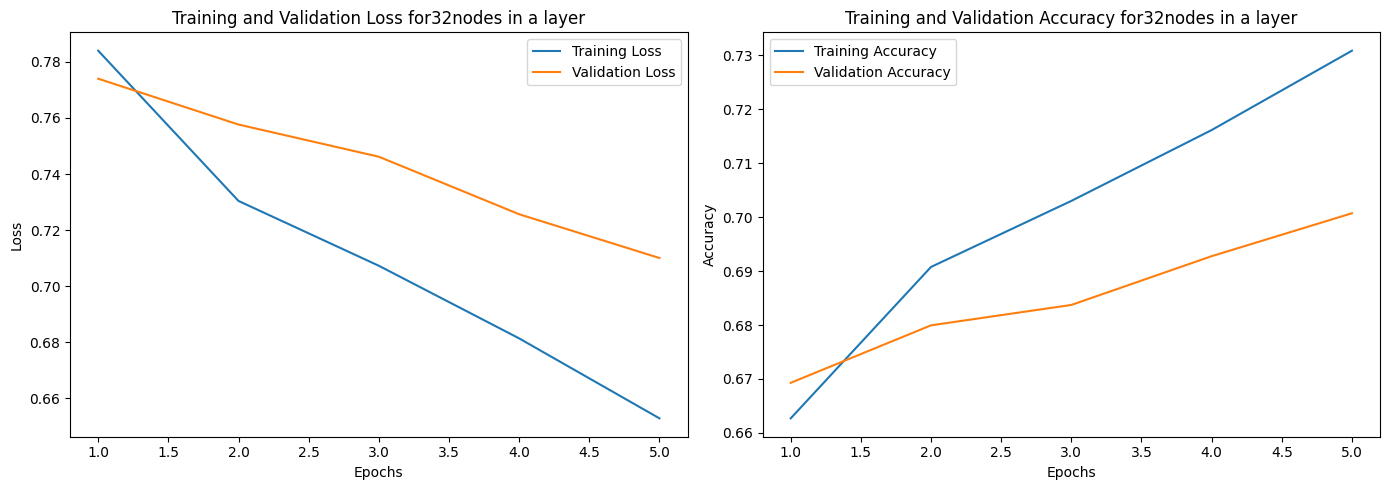

233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
### ------------------------------------------------------###

### Experiment results  for Neural networl Hidden layer nodes = 64  ###


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_42 (Dense)                     │ (None, 64)                  │          29,632 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_43 (Dense)                     │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,827 (116.51 KB)

 Trainable params: 29,827 (116.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6277 - loss: 0.8352 - val_accuracy: 0.6694 - val_loss: 0.7627
Epoch 2/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.6976 - loss: 0.7182 - val_accuracy: 0.6835 - val_loss: 0.7443
Epoch 3/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7211 - loss: 0.6708 - val_accuracy: 0.7048 - val_loss: 0.7090
Epoch 4/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7408 - loss: 0.6306 - val_accuracy: 0.7033 - val_loss: 0.7101
Epoch 5/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7561 - loss: 0.5984 - val_accuracy: 0.7022 - val_loss: 0.7060


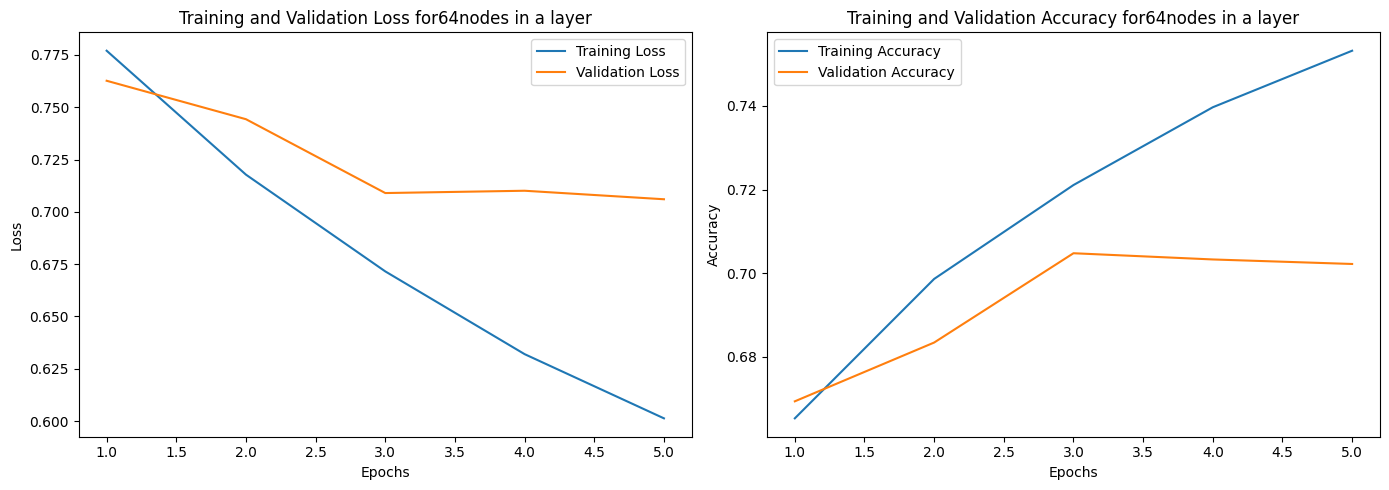

233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
### ------------------------------------------------------###

### Experiment results  for Neural networl Hidden layer nodes = 128  ###


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_44 (Dense)                     │ (None, 128)                 │          59,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_45 (Dense)                     │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 59,651 (233.01 KB)

 Trainable params: 59,651 (233.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6409 - loss: 0.8171 - val_accuracy: 0.6749 - val_loss: 0.7610
Epoch 2/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.7035 - loss: 0.7084 - val_accuracy: 0.6936 - val_loss: 0.7175
Epoch 3/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7383 - loss: 0.6359 - val_accuracy: 0.7076 - val_loss: 0.6973
Epoch 4/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7640 - loss: 0.5813 - val_accuracy: 0.7090 - val_loss: 0.6994
Epoch 5/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7883 - loss: 0.5288 - val_accuracy: 0.7033 - val_loss: 0.7035


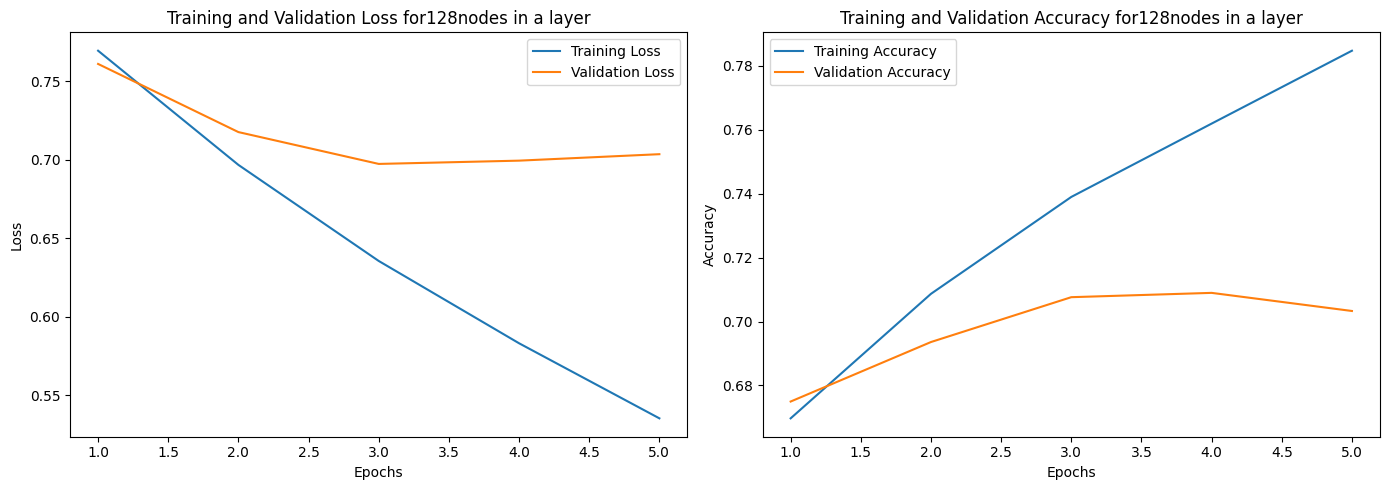

233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
### ------------------------------------------------------###

### Experiment results  for Neural networl Hidden layer nodes = 256  ###


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_46 (Dense)                     │ (None, 256)                 │         118,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_47 (Dense)                     │ (None, 3)                   │             771 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 119,299 (466.01 KB)

 Trainable params: 119,299 (466.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.6343 - loss: 0.8196 - val_accuracy: 0.6849 - val_loss: 0.7466
Epoch 2/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.7170 - loss: 0.6807 - val_accuracy: 0.7033 - val_loss: 0.7075
Epoch 3/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.7615 - loss: 0.5916 - val_accuracy: 0.7161 - val_loss: 0.6875
Epoch 4/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - accuracy: 0.7910 - loss: 0.5198 - val_accuracy: 0.7057 - val_loss: 0.7129
Epoch 5/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.8334 - loss: 0.4348 - val_accuracy: 0.6995 - val_loss: 0.7330


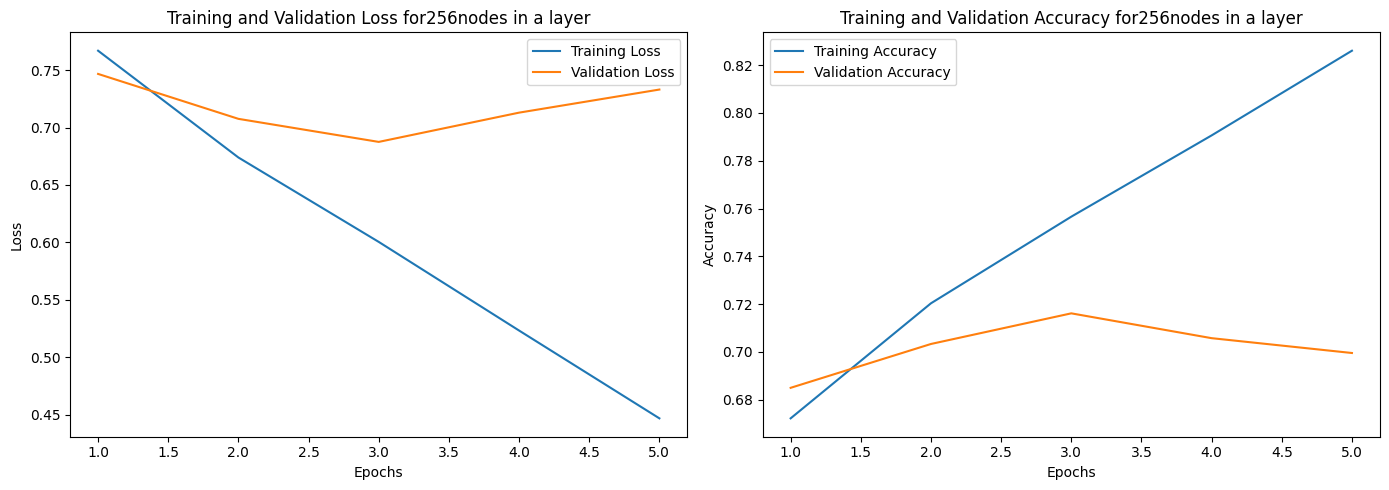

233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
### ------------------------------------------------------###

### Experiment results  for Neural networl Hidden layer nodes = 512  ###


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                     │ (None, 512)                 │         237,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_49 (Dense)                     │ (None, 3)                   │           1,539 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 238,595 (932.01 KB)

 Trainable params: 238,595 (932.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.6493 - loss: 0.8053 - val_accuracy: 0.6824 - val_loss: 0.7448
Epoch 2/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7305 - loss: 0.6594 - val_accuracy: 0.7102 - val_loss: 0.6919
Epoch 3/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.7752 - loss: 0.5578 - val_accuracy: 0.7145 - val_loss: 0.6982
Epoch 4/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - accuracy: 0.8299 - loss: 0.4419 - val_accuracy: 0.6995 - val_loss: 0.7572
Epoch 5/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8787 - loss: 0.3336 - val_accuracy: 0.7049 - val_loss: 0.7838


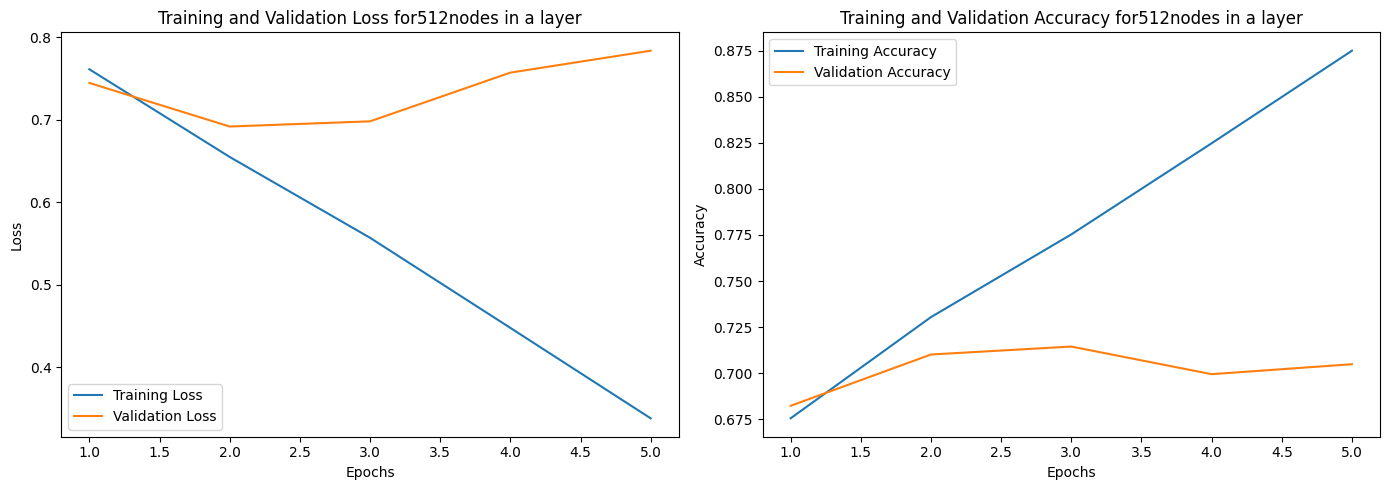

233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
### ------------------------------------------------------###


In [ ]:

## Neural network 1 hidden layer
neural_model = tf.keras.Sequential()
# input layer with 462 nurons which is connected with hidden layer with 1 nodes
print('\n### Experiment results  for Neural network Hidden layer nodes = 1  ###')
neural_model.add(tf.keras.layers.Dense(1, input_dim=462, activation='relu'))
#output layer with 3 nodes and 'softmoc as activation func
neural_model.add(tf.keras.layers.Dense(3, activation='softmax'))
neural_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
neural_model.summary()
print('###Graph for single node for single hidden layer with 5 epoch####')
history_L1_E5= neural_model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_validation, y_validation))
plot_graph(history_L1_E5,' 1 nodes in a layer epoch 5' )
history_L1_E50= neural_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_validation, y_validation))
print('###Graph for single node for single hidden layer with 50 epoch####')
plot_graph(history_L1_E50, ' 1 nodes in a layer epoch 50')
y_pred_neural = neural_model.predict(X_test)



### Neural network 2 nodes in a single hidden layer
neural_model = tf.keras.Sequential()
# input layer with 462 nurons which is connected with a hidden layer with 2 nodes
print('\n### Experiment results  for Neural network a hidden layer nodes = 2  ###')
neural_model.add(tf.keras.layers.Dense(2, input_dim=462, activation='relu'))
#output layer with 3 nodes and 'softmoc as activation func
neural_model.add(tf.keras.layers.Dense(3, activation='softmax'))
neural_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
neural_model.summary()
history_L1_N2 = neural_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_validation, y_validation))
print('###Graph for single hidden layer with 2 nodes ####')
plot_graph(history_L1_N2, ' 2 nodes in a layer')
y_pred_neural = neural_model.predict(X_test)


### Neural network 4 nodes in a single hidden layer
neural_model = tf.keras.Sequential()
# input layer with 462 nurons which is connected with a hidden layer with 4 nodes
print('\n### Experiment results  for Neural network Hidden layer nodes = 4  ###')
neural_model.add(tf.keras.layers.Dense(4, input_dim=462, activation='relu'))
#output layer with 3 nodes and 'softmoc as activation func
neural_model.add(tf.keras.layers.Dense(3, activation='softmax'))
neural_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
neural_model.summary()
history_L1_N4 = neural_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_validation, y_validation))
print('###Graph for single hidden layer with 4 nodes ####')
plot_graph(history_L1_N4, ' 4 nodes in a layer')
y_pred_neural = neural_model.predict(X_test)


### Progressively update the number of hidden layers 8, 16, 32, 64, 128, 256, 512
nodes = [8, 16, 32, 64, 128, 256, 512]
for i in range(len(nodes)):
    neural_model = tf.keras.Sequential()
    print('\n### Experiment results  for Neural networl Hidden layer nodes = {}  ###'.format  (nodes[i]))
    neural_model.add(tf.keras.layers.Dense(nodes[i], input_dim=462, activation='relu'))
    neural_model.add(tf.keras.layers.Dense(3, activation='softmax'))
    neural_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    neural_model.summary()
    history = neural_model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_validation, y_validation))
    plot_graph(history, str(nodes[i])+ 'nodes in a layer')
    y_pred_neural = neural_model.predict(X_test)
    print('### ------------------------------------------------------###')



**Observation**:
For both cases where epochs=5 and epochs=50 with a single node in a single hidden layer, the network is underfitting. As we can see from the graph that with a node in a single hidden layer and relatively lower epoch, the training loss is smaller than the validation loss and training accuracy is greater than validation accuracy. Similarly, graph that with a node in a single hidden layer and relatively higher epochs=50,  the training loss is smaller than the validation loss and training accuracy is greater than validation accuracy. Since the accuracy decreases and loss increases both with smaller/greater epoch for a single hidden layer network, the model is definitly underfitting.

    - **Varying the number of layers**.

        - Conduct similar experiments as described above, but this time vary the number of layers from 1 to 4. Document your findings.

        - How many nodes should each layer contain? Test at least two scenarios. Traditionally, a common strategy involved decreasing the number of nodes from the input layer to the output layer, often by halving, to create a pyramid-like structure. However, recent experience suggests that maintaining a constant number of nodes across all layers can perform equally well. Describe your observations. It is acceptable if both strategies yield similar performance results.

        - Select one your models that exemplifies overfitting. In our experiments, we easily constructed a model achieving nearly 100% accuracy on the training data, yet showing no similar improvement on the validation set. Present this neural network along with its accuracy and loss graphs. Explain the reasoning for concluding that the model is overfitting.


### Experiment results  for Neural networl Hidden layer = 1  ###


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_57"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_187 (Dense)                    │ (None, 1)                   │             463 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_188 (Dense)                    │ (None, 3)                   │               6 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 469 (1.83 KB)

 Trainable params: 469 (1.83 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5170 - loss: 1.0096 - val_accuracy: 0.5841 - val_loss: 0.9236
Epoch 2/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6043 - loss: 0.8976 - val_accuracy: 0.5938 - val_loss: 0.9055
Epoch 3/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6165 - loss: 0.8777 - val_accuracy: 0.5957 - val_loss: 0.9004
Epoch 4/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6204 - loss: 0.8682 - val_accuracy: 0.5999 - val_loss: 0.8948
Epoch 5/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6208 - loss: 0.8643 - val_accuracy: 0.5994 - val_loss: 0.8939


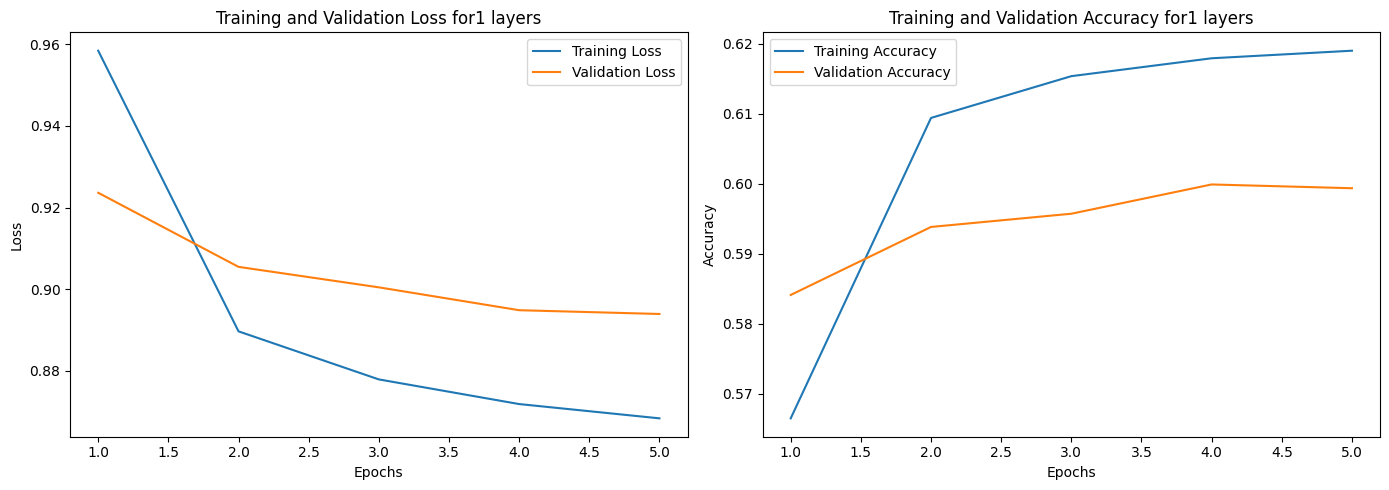

233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
### ------------------------------------------------------###

### Experiment results  for Neural networl Hidden layer = 2  ###


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_58"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_189 (Dense)                    │ (None, 2)                   │             926 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_190 (Dense)                    │ (None, 3)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 935 (3.65 KB)

 Trainable params: 935 (3.65 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4726 - loss: 1.0165 - val_accuracy: 0.5657 - val_loss: 0.9191
Epoch 2/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5923 - loss: 0.8919 - val_accuracy: 0.5949 - val_loss: 0.8732
Epoch 3/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6446 - loss: 0.8291 - val_accuracy: 0.6679 - val_loss: 0.7942
Epoch 4/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6846 - loss: 0.7654 - val_accuracy: 0.6720 - val_loss: 0.7799
Epoch 5/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6918 - loss: 0.7436 - val_accuracy: 0.6752 - val_loss: 0.7722


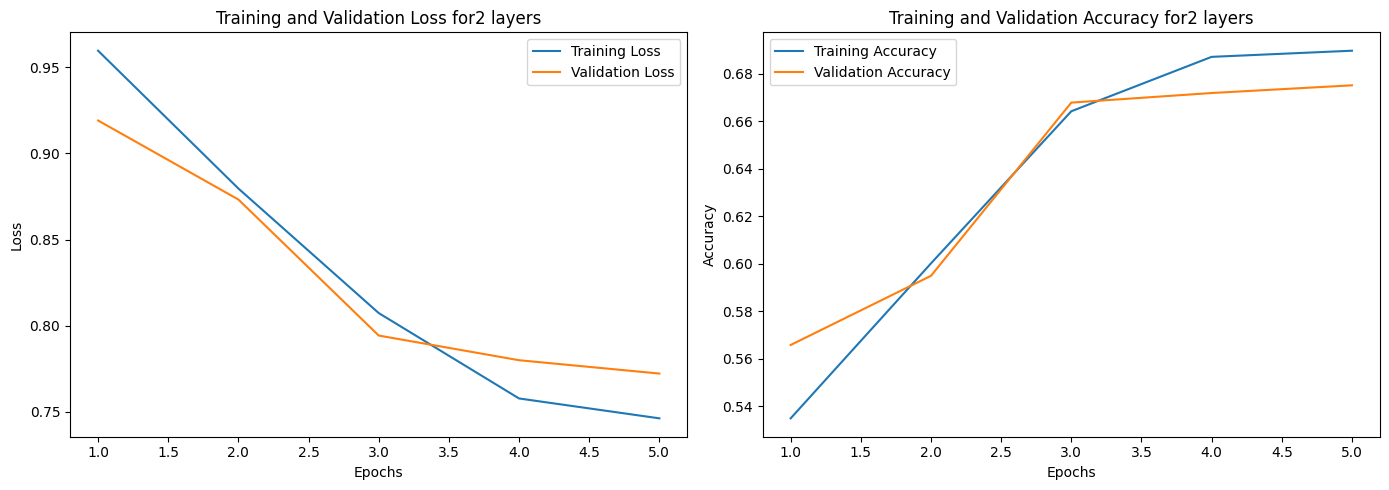

233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
### ------------------------------------------------------###

### Experiment results  for Neural networl Hidden layer = 3  ###


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_59"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_191 (Dense)                    │ (None, 3)                   │           1,389 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_192 (Dense)                    │ (None, 3)                   │              12 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,401 (5.47 KB)

 Trainable params: 1,401 (5.47 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5101 - loss: 0.9967 - val_accuracy: 0.6739 - val_loss: 0.8005
Epoch 2/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6870 - loss: 0.7661 - val_accuracy: 0.6724 - val_loss: 0.7756
Epoch 3/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6896 - loss: 0.7438 - val_accuracy: 0.6745 - val_loss: 0.7756
Epoch 4/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6943 - loss: 0.7389 - val_accuracy: 0.6686 - val_loss: 0.7729
Epoch 5/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6920 - loss: 0.7373 - val_accuracy: 0.6683 - val_loss: 0.7727


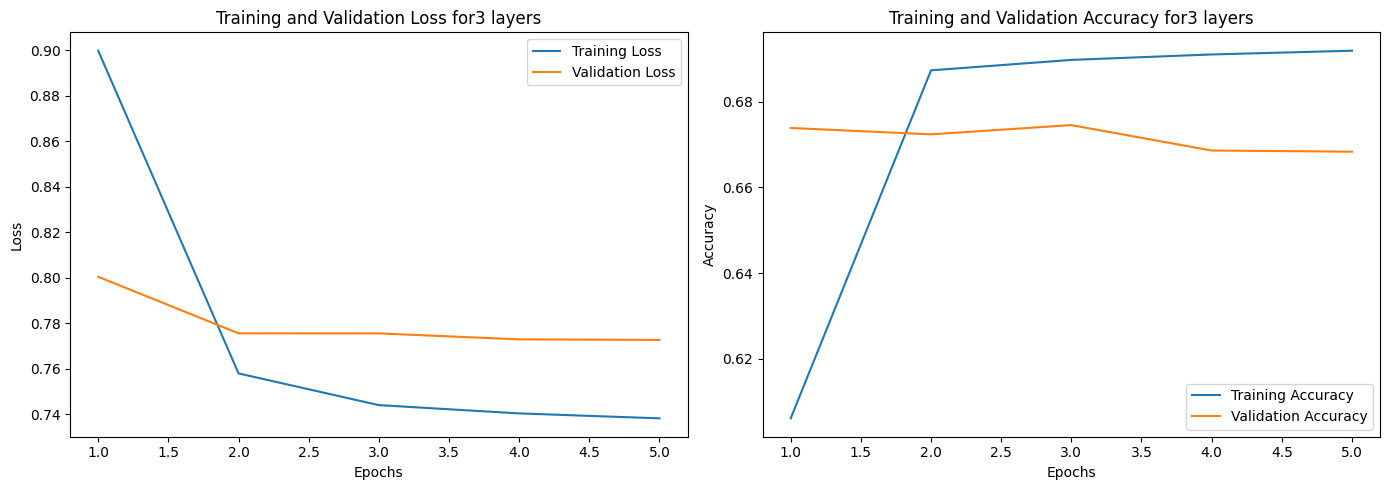

233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
### ------------------------------------------------------###

### Experiment results  for Neural networl Hidden layer = 4  ###


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_60"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_193 (Dense)                    │ (None, 4)                   │           1,852 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_194 (Dense)                    │ (None, 3)                   │              15 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,867 (7.29 KB)

 Trainable params: 1,867 (7.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5457 - loss: 0.9547 - val_accuracy: 0.6740 - val_loss: 0.7774
Epoch 2/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6903 - loss: 0.7435 - val_accuracy: 0.6731 - val_loss: 0.7689
Epoch 3/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6922 - loss: 0.7275 - val_accuracy: 0.6752 - val_loss: 0.7656
Epoch 4/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6929 - loss: 0.7311 - val_accuracy: 0.6690 - val_loss: 0.7656
Epoch 5/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6950 - loss: 0.7257 - val_accuracy: 0.6763 - val_loss: 0.7617


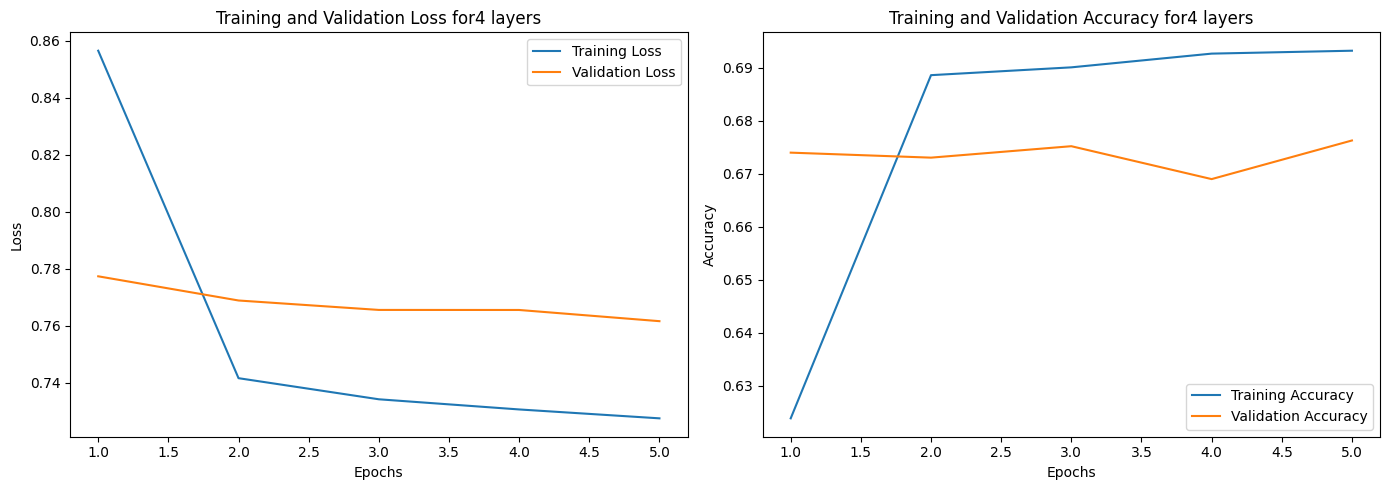

233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
### ------------------------------------------------------###


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_61"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_195 (Dense)                    │ (None, 48)                  │          22,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_196 (Dense)                    │ (None, 24)                  │           1,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_197 (Dense)                    │ (None, 12)                  │             300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_198 (Dense)                    │ (None, 6)                   │              78 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_199 (Dense)                    │ (None, 3)                   │              21 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,799 (92.96 KB)

 Trainable params: 23,799 (92.96 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.5812 - loss: 0.8943 - val_accuracy: 0.6671 - val_loss: 0.7755
Epoch 2/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6919 - loss: 0.7229 - val_accuracy: 0.6859 - val_loss: 0.7427
Epoch 3/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7202 - loss: 0.6743 - val_accuracy: 0.6975 - val_loss: 0.7164
Epoch 4/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7380 - loss: 0.6256 - val_accuracy: 0.6975 - val_loss: 0.7171
Epoch 5/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7610 - loss: 0.5841 - val_accuracy: 0.6975 - val_loss: 0.7150


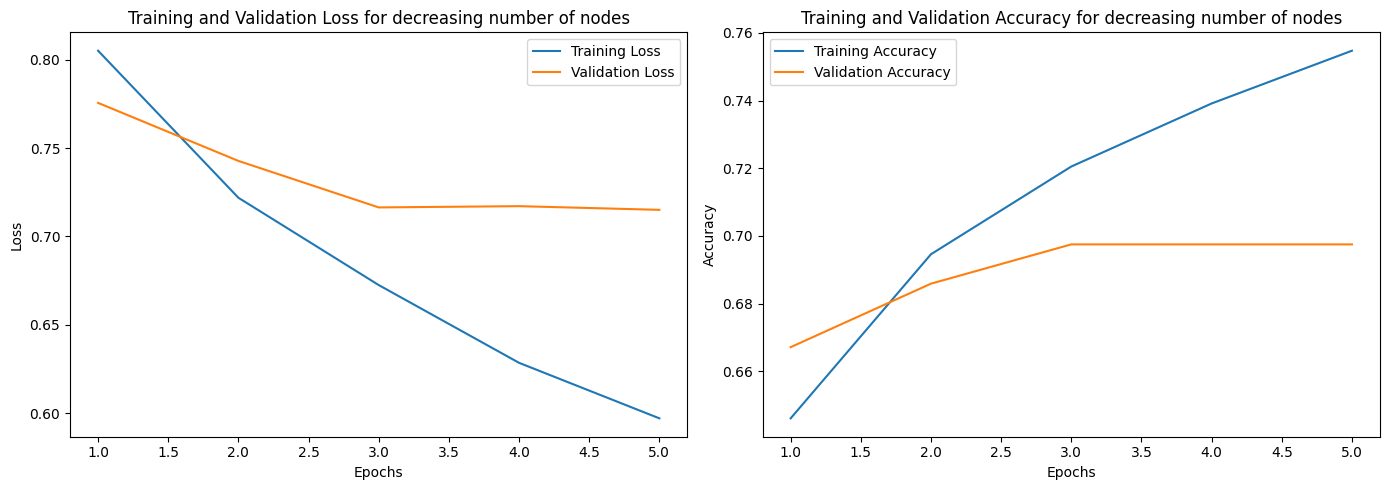

233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
### ------------------------------------------------------###


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_62"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_200 (Dense)                    │ (None, 24)                  │          11,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_201 (Dense)                    │ (None, 24)                  │             600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_202 (Dense)                    │ (None, 24)                  │             600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_203 (Dense)                    │ (None, 24)                  │             600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_204 (Dense)                    │ (None, 24)                  │             600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_205 (Dense)                    │ (None, 3)                   │              75 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,587 (53.07 KB)

 Trainable params: 13,587 (53.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.5986 - loss: 0.8603 - val_accuracy: 0.6697 - val_loss: 0.7817
Epoch 2/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6934 - loss: 0.7238 - val_accuracy: 0.6874 - val_loss: 0.7523
Epoch 3/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7135 - loss: 0.6881 - val_accuracy: 0.6907 - val_loss: 0.7336
Epoch 4/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7291 - loss: 0.6566 - val_accuracy: 0.6921 - val_loss: 0.7288
Epoch 5/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7409 - loss: 0.6294 - val_accuracy: 0.6818 - val_loss: 0.7367


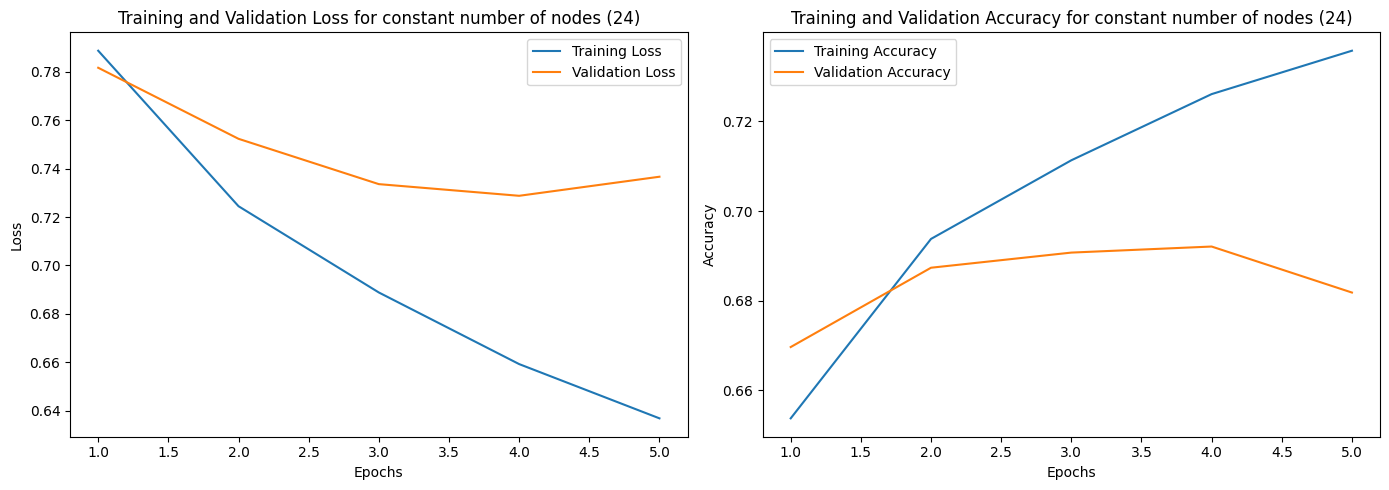

233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
### ------------------------------------------------------###


In [44]:
#varying number of layer from 1 to 4
for i in range(1,5):
    neural_model = tf.keras.Sequential()
    print('\n### Experiment results  for Neural network Hidden layer = {}  ###'.format  (i))
    neural_model.add(tf.keras.layers.Dense(i, input_dim=462, activation='relu'))
    neural_model.add(tf.keras.layers.Dense(3, activation='softmax'))
    neural_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    neural_model.summary()
    history = neural_model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_validation, y_validation))
    plot_graph(history, str(i)+' layers')
    y_pred_neural = neural_model.predict(X_test)
    print('### ------------------------------------------------------###')

## varying number of nodes in each layer
###Scenario 1: decreasing the number of nodes from the input layer to the output layer, often by halving
neural_model_s1= tf.keras.Sequential()
#first hidden layer with 48 nodes
neural_model_s1.add(tf.keras.layers.Dense(48, input_dim=462, activation='relu'))
#second hidden layer with 24 nodes
neural_model_s1.add(tf.keras.layers.Dense(24, activation='relu'))
#third hidden layer with 12 nodes
neural_model_s1.add(tf.keras.layers.Dense(12, activation='relu'))
#fourth hidden layer with 6 nodes
neural_model_s1.add(tf.keras.layers.Dense(6, activation='relu'))
#output layer
neural_model_s1.add(tf.keras.layers.Dense(3, activation='softmax'))
neural_model_s1.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
neural_model_s1.summary()
history_exp_dec_nodes = neural_model_s1.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_validation, y_validation))
plot_graph(history_exp_dec_nodes, ' decreasing number of nodes')
y_pred_neural = neural_model_s1.predict(X_test)
print('### ------------------------------------------------------###')


###Scenario 2: maintaining a constant number of nodes across all layers
neural_mode_s2 = tf.keras.Sequential()
numOfnodes = 24
for i in range(0,5):
  if i == 0:
    neural_mode_s2.add(tf.keras.layers.Dense(numOfnodes, input_dim=462, activation='relu'))
  else:
    neural_mode_s2.add(tf.keras.layers.Dense(numOfnodes, activation='relu'))

neural_mode_s2.add(tf.keras.layers.Dense(3, activation='softmax'))
neural_mode_s2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
neural_mode_s2.summary()
history_exp_const_nodes = neural_mode_s2.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_validation, y_validation))
plot_graph(history_exp_const_nodes, ' constant number of nodes (24)')
y_pred_neural = neural_mode_s2.predict(X_test)
print('### ------------------------------------------------------###')




    - **Activation function**.

        - Present results for one of the configurations mentioned above by varying the activation function. Test at least `relu` (the default) and `sigmoid`. The choice of the specific model, including the number of layers and nodes, is at your discretion. Document your observations accordingly.

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_93 (Dense)                     │ (None, 48)                  │          22,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_94 (Dense)                     │ (None, 24)                  │           1,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_95 (Dense)                     │ (None, 12)                  │             300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_96 (Dense)                     │ (None, 6)                   │              78 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_97 (Dense)                     │ (None, 3)                   │              21 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,799 (92.96 KB)

 Trainable params: 23,799 (92.96 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.5497 - loss: 0.9588 - val_accuracy: 0.6675 - val_loss: 0.7942
Epoch 2/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6923 - loss: 0.7448 - val_accuracy: 0.6722 - val_loss: 0.7686
Epoch 3/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6971 - loss: 0.7244 - val_accuracy: 0.6826 - val_loss: 0.7494
Epoch 4/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7079 - loss: 0.7013 - val_accuracy: 0.6848 - val_loss: 0.7397
Epoch 5/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7168 - loss: 0.6802 - val_accuracy: 0.6852 - val_loss: 0.7365


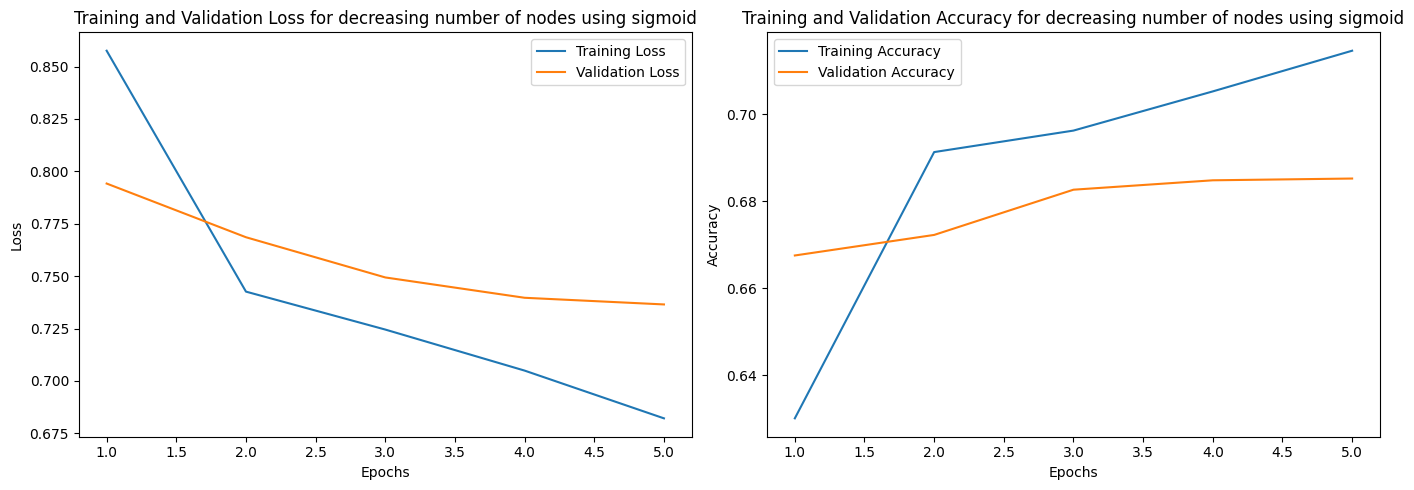

233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
### ------------------------------------------------------###


In [33]:

###Scenario 1: decreasing the number of nodes from the input layer to the output layer, often by halving
neural_model_s1= tf.keras.Sequential()
#first hidden layer with 48 nodes
neural_model_s1.add(tf.keras.layers.Dense(48, input_dim=462, activation='relu'))
#second hidden layer with 24 nodes
neural_model_s1.add(tf.keras.layers.Dense(24, activation='sigmoid'))
#third hidden layer with 12 nodes
neural_model_s1.add(tf.keras.layers.Dense(12, activation='sigmoid'))
#fourth hidden layer with 6 nodes
neural_model_s1.add(tf.keras.layers.Dense(6, activation='sigmoid'))
#output layer
neural_model_s1.add(tf.keras.layers.Dense(3, activation='softmax'))
neural_model_s1.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
neural_model_s1.summary()
history_exp_dec_nodes = neural_model_s1.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_validation, y_validation))
plot_graph(history_exp_dec_nodes, ' decreasing number of nodes using sigmoid')
y_pred_neural = neural_model_s1.predict(X_test)
print('### ------------------------------------------------------###')

    - **Regularization** in neural networks is a technique used to prevent overfitting.

        - One technique involves adding a penalty to the loss function to discourage excessively complex models. Apply an `l2` penalty to some or all layers. Exercise caution, as overly aggressive penalties have been problematic in our experiments. Begin with the default `l2` value of 0.01, then reduce it to 0.001 and 1e-4. Select a specific model from the above experiments and present a case where you successfully reduced overfitting. Include a pair of graphs comparing results with and without regularization. Explain your rationale to conclude that overfitting has been reduced. Do not expect to completely eliminate overfitting. Again, this is a challenging dataset to work with.

Model: "sequential_64"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_19 (Flatten)                 │ (None, 462)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_211 (Dense)                    │ (None, 48)                  │          22,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_212 (Dense)                    │ (None, 24)                  │           1,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_213 (Dense)                    │ (None, 12)                  │             300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_214 (Dense)                    │ (None, 6)                   │              78 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_215 (Dense)                    │ (None, 3)                   │              21 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,799 (92.96 KB)

 Trainable params: 23,799 (92.96 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.5919 - loss: 0.9550 - val_accuracy: 0.6664 - val_loss: 0.8350
Epoch 2/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6907 - loss: 0.7924 - val_accuracy: 0.6817 - val_loss: 0.8039
Epoch 3/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7134 - loss: 0.7499 - val_accuracy: 0.6883 - val_loss: 0.7873
Epoch 4/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7227 - loss: 0.7283 - val_accuracy: 0.6924 - val_loss: 0.7860
Epoch 5/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7283 - loss: 0.7172 - val_accuracy: 0.6968 - val_loss: 0.7790


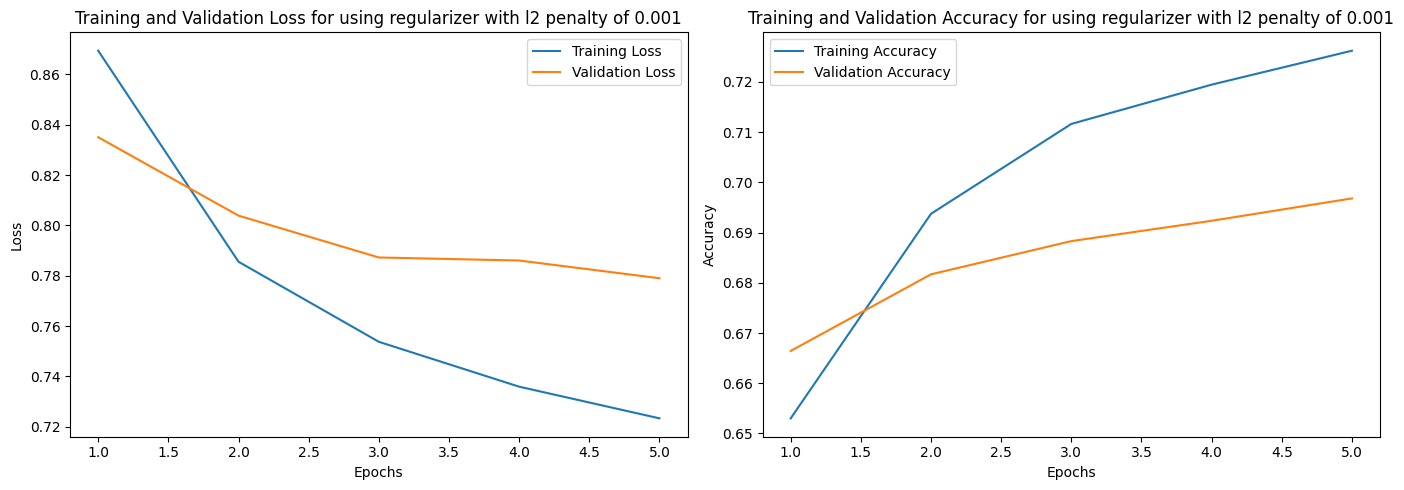

233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
### ------------------------------------------------------###


Model: "sequential_65"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_20 (Flatten)                 │ (None, 462)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_216 (Dense)                    │ (None, 48)                  │          22,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_217 (Dense)                    │ (None, 24)                  │           1,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_218 (Dense)                    │ (None, 12)                  │             300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_219 (Dense)                    │ (None, 6)                   │              78 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_220 (Dense)                    │ (None, 3)                   │              21 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,799 (92.96 KB)

 Trainable params: 23,799 (92.96 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.5709 - loss: 1.2369 - val_accuracy: 0.5914 - val_loss: 0.9980
Epoch 2/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6070 - loss: 0.9605 - val_accuracy: 0.6571 - val_loss: 0.9432
Epoch 3/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6690 - loss: 0.9115 - val_accuracy: 0.6628 - val_loss: 0.9122
Epoch 4/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6764 - loss: 0.8842 - val_accuracy: 0.6551 - val_loss: 0.9210
Epoch 5/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6814 - loss: 0.8735 - val_accuracy: 0.6605 - val_loss: 0.8945


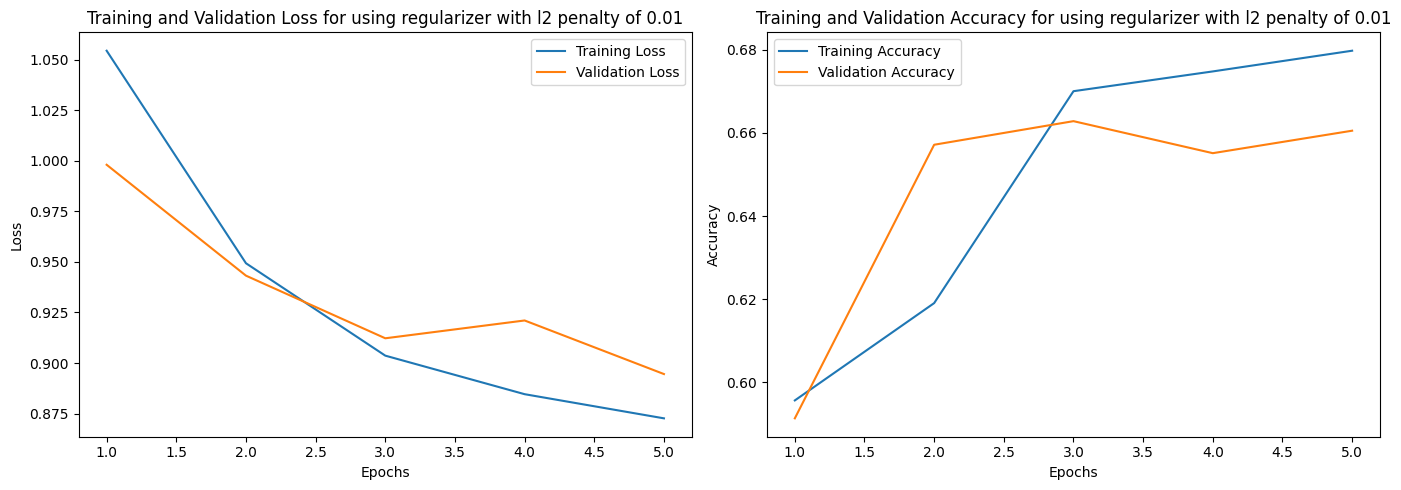

233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
### ------------------------------------------------------###


Model: "sequential_66"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_21 (Flatten)                 │ (None, 462)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_221 (Dense)                    │ (None, 48)                  │          22,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_222 (Dense)                    │ (None, 24)                  │           1,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_223 (Dense)                    │ (None, 12)                  │             300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_224 (Dense)                    │ (None, 6)                   │              78 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_225 (Dense)                    │ (None, 3)                   │              21 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,799 (92.96 KB)

 Trainable params: 23,799 (92.96 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5926 - loss: 0.8824 - val_accuracy: 0.6770 - val_loss: 0.7756
Epoch 2/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.6968 - loss: 0.7404 - val_accuracy: 0.6822 - val_loss: 0.7650
Epoch 3/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7230 - loss: 0.6878 - val_accuracy: 0.7040 - val_loss: 0.7393
Epoch 4/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7421 - loss: 0.6433 - val_accuracy: 0.7061 - val_loss: 0.7407
Epoch 5/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7570 - loss: 0.6181 - val_accuracy: 0.6988 - val_loss: 0.7536


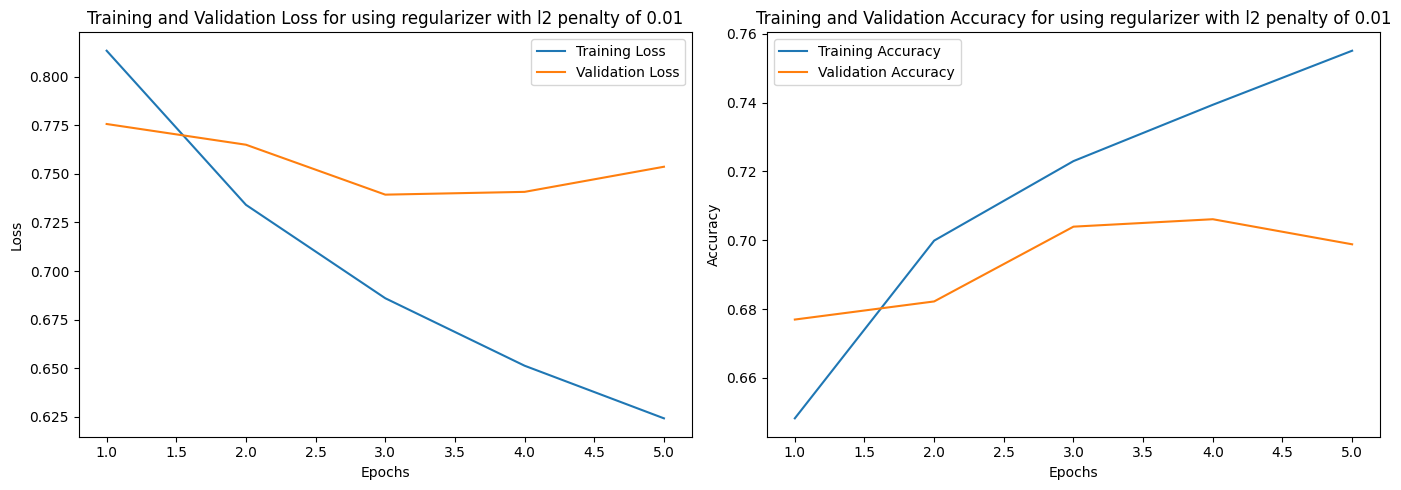

233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
### ------------------------------------------------------###


In [46]:
# Code cell
###Scenario 1: decreasing the number of nodes from the input layer to the output layer, often by halving

import keras
from keras.models import Sequential
from keras.layers import InputLayer, Dropout, Flatten, Dense

regularizer = tf.keras.regularizers.l2(0.001)
neural_mode_s2 = tf.keras.Sequential([
 InputLayer(shape=[462,]),
 Flatten(),
 Dense(48, activation='relu', kernel_regularizer=regularizer),
 Dense(24, activation='relu', kernel_regularizer=regularizer),
 Dense(12, activation='relu', kernel_regularizer=regularizer),
 Dense(6, activation='relu', kernel_regularizer=regularizer),
 Dense(3, activation='softmax')
])

neural_mode_s2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
neural_mode_s2.summary()
history_exp_const_nodes = neural_mode_s2.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_validation, y_validation))
plot_graph(history_exp_const_nodes, ' using regularizer with l2 penalty of 0.001')
y_pred_neural = neural_mode_s2.predict(X_test)
print('### ------------------------------------------------------###')

########

regularizer = tf.keras.regularizers.l2(0.01)
neural_mode_s2 = tf.keras.Sequential([
 InputLayer(shape=[462,]),
 Flatten(),
 Dense(48, activation='relu', kernel_regularizer=regularizer),
 Dense(24, activation='relu', kernel_regularizer=regularizer),
 Dense(12, activation='relu', kernel_regularizer=regularizer),
 Dense(6, activation='relu', kernel_regularizer=regularizer),
 Dense(3, activation='softmax')
])

neural_mode_s2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
neural_mode_s2.summary()
history_exp_const_nodes = neural_mode_s2.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_validation, y_validation))
plot_graph(history_exp_const_nodes, ' using regularizer with l2 penalty of 0.01')
y_pred_neural = neural_mode_s2.predict(X_test)
print('### ------------------------------------------------------###')


regularizer = tf.keras.regularizers.l2(0.0001)
neural_mode_s2 = tf.keras.Sequential([
 InputLayer(shape=[462,]),
 Flatten(),
 Dense(48, activation='relu', kernel_regularizer=regularizer),
 Dense(24, activation='relu', kernel_regularizer=regularizer),
 Dense(12, activation='relu', kernel_regularizer=regularizer),
 Dense(6, activation='relu', kernel_regularizer=regularizer),
 Dense(3, activation='softmax')
])

neural_mode_s2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
neural_mode_s2.summary()
history_exp_const_nodes = neural_mode_s2.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_validation, y_validation))
plot_graph(history_exp_const_nodes, ' using regularizer with l2 penalty of 0.0001')
y_pred_neural = neural_mode_s2.predict(X_test)
print('### ------------------------------------------------------###')

        - Dropout layers are a regularization technique in neural networks where a random subset of neurons is temporarily removed during training. This helps prevent overfitting by promoting redundancy and improving the network's ability to generalize to new data. Select a specific model from the above experiments where you have muliple layers and experiment adding one or of few dropout layers into your network. Experiment with two different rates, say 0.25 and 0.5. Document your observations.

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 462)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 462)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 48)                  │          22,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 48)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 24)                  │           1,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 24)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 12)                  │             300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 12)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 6)                   │              78 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 6)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 3)                   │              21 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,799 (92.96 KB)

 Trainable params: 23,799 (92.96 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.4726 - loss: 1.0237 - val_accuracy: 0.6663 - val_loss: 0.8259
Epoch 2/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6142 - loss: 0.8876 - val_accuracy: 0.6670 - val_loss: 0.8211
Epoch 3/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6233 - loss: 0.8701 - val_accuracy: 0.6743 - val_loss: 0.8159
Epoch 4/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.6296 - loss: 0.8572 - val_accuracy: 0.6803 - val_loss: 0.7825
Epoch 5/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6445 - loss: 0.8409 - val_accuracy: 0.6920 - val_loss: 0.7723


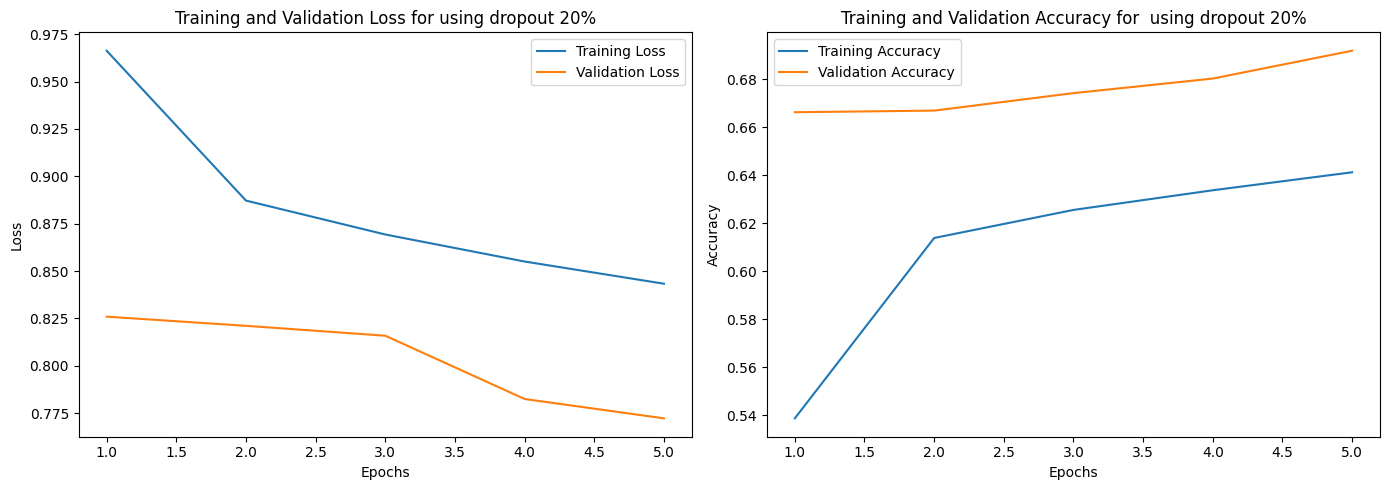

233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
### ------------------------------------------------------###


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (None, 462)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 462)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 48)                  │          22,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 48)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 24)                  │           1,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 24)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 12)                  │             300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 12)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 6)                   │              78 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 6)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 3)                   │              21 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,799 (92.96 KB)

 Trainable params: 23,799 (92.96 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.4014 - loss: 1.0947 - val_accuracy: 0.4631 - val_loss: 1.0770
Epoch 2/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.4583 - loss: 1.0612 - val_accuracy: 0.5926 - val_loss: 1.0087
Epoch 3/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.5093 - loss: 1.0313 - val_accuracy: 0.5953 - val_loss: 0.9887
Epoch 4/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5178 - loss: 1.0231 - val_accuracy: 0.5838 - val_loss: 0.9839
Epoch 5/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5246 - loss: 1.0196 - val_accuracy: 0.5933 - val_loss: 0.9702


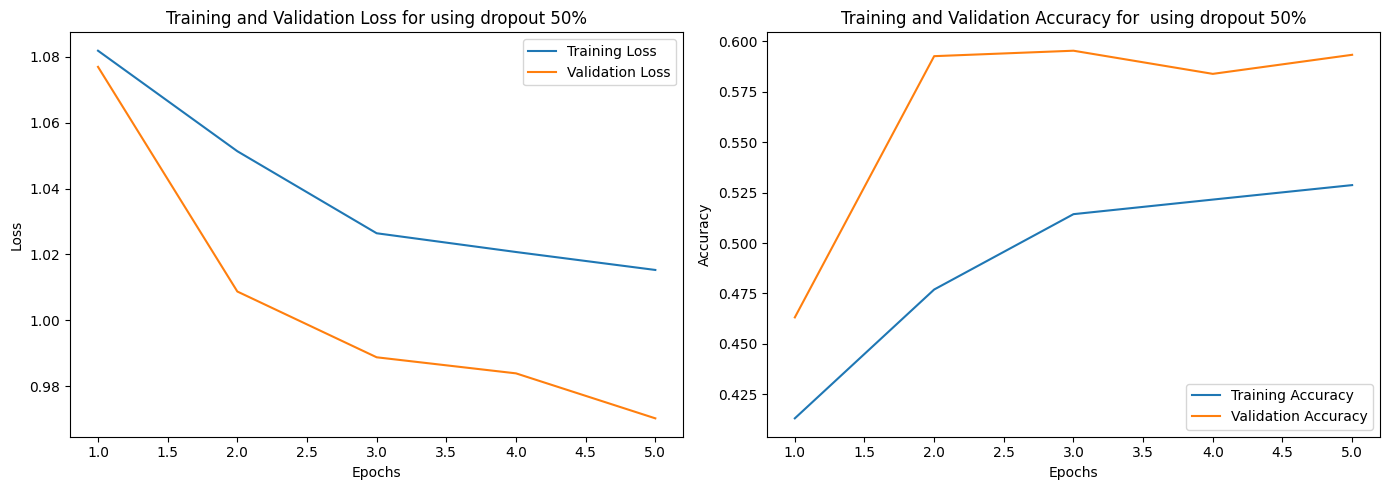

233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
### ------------------------------------------------------###


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)                  │ (None, 462)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ (None, 462)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 48)                  │          22,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_16 (Dropout)                 │ (None, 48)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 24)                  │           1,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_17 (Dropout)                 │ (None, 24)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 12)                  │             300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_18 (Dropout)                 │ (None, 12)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 6)                   │              78 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_19 (Dropout)                 │ (None, 6)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 3)                   │              21 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,799 (92.96 KB)

 Trainable params: 23,799 (92.96 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.5499 - loss: 0.9521 - val_accuracy: 0.6741 - val_loss: 0.7977
Epoch 2/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6546 - loss: 0.8237 - val_accuracy: 0.6763 - val_loss: 0.7867
Epoch 3/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.6684 - loss: 0.8015 - val_accuracy: 0.6829 - val_loss: 0.7664
Epoch 4/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6889 - loss: 0.7641 - val_accuracy: 0.6996 - val_loss: 0.7433
Epoch 5/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6971 - loss: 0.7411 - val_accuracy: 0.6987 - val_loss: 0.7414


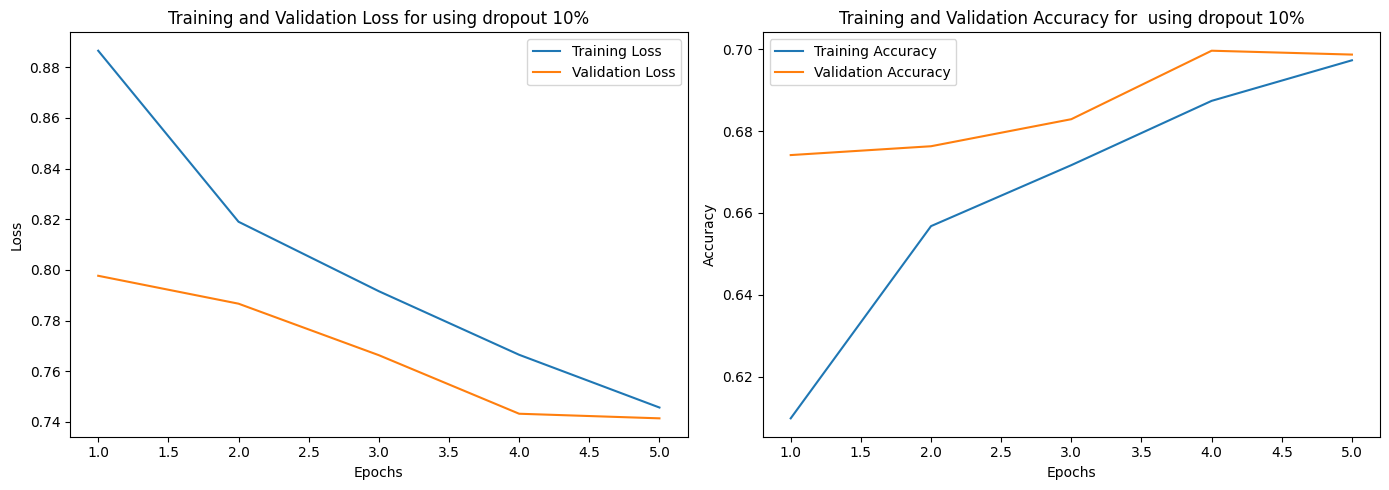

233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
### ------------------------------------------------------###


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                     │ (None, 48)                  │          22,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 12)                  │             588 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 6)                   │              78 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 3)                   │              21 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,911 (89.50 KB)

 Trainable params: 22,911 (89.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6142 - loss: 0.8620 - val_accuracy: 0.6728 - val_loss: 0.7757
Epoch 2/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6990 - loss: 0.7298 - val_accuracy: 0.6880 - val_loss: 0.7506
Epoch 3/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7191 - loss: 0.6863 - val_accuracy: 0.6980 - val_loss: 0.7412
Epoch 4/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7391 - loss: 0.6505 - val_accuracy: 0.7003 - val_loss: 0.7281
Epoch 5/5
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7556 - loss: 0.6216 - val_accuracy: 0.6976 - val_loss: 0.7318


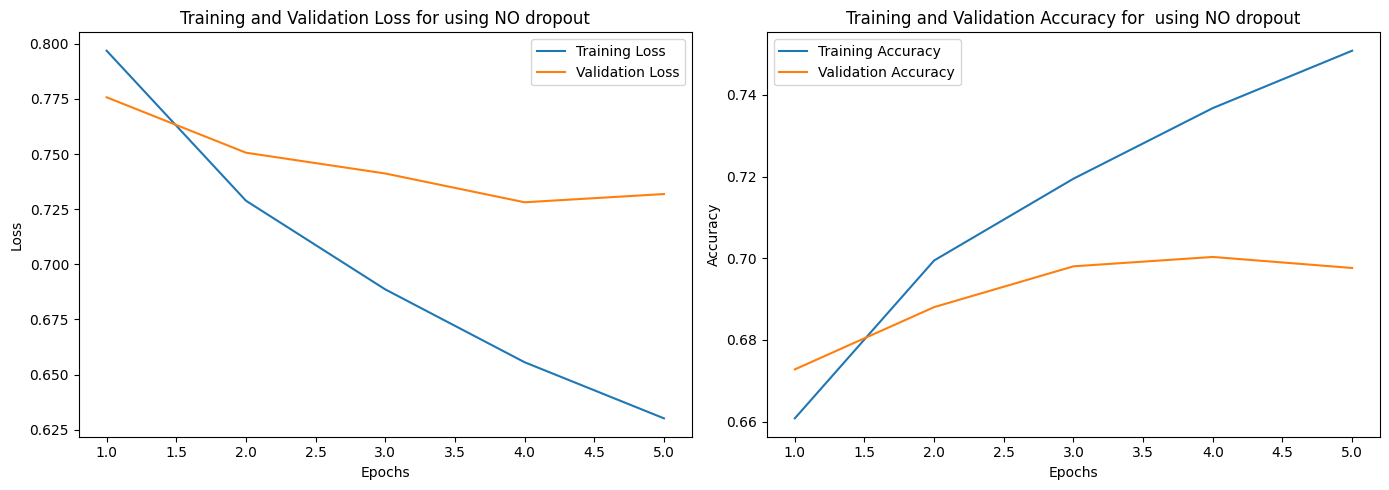

233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
### ------------------------------------------------------###


In [15]:
###Scenario 1: decreasing the number of nodes from the input layer to the output layer, often by halving

import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import InputLayer, Dropout, Flatten, Dense

regularizer = tf.keras.regularizers.l2(0.0001)

neural_mode_s2 = tf.keras.Sequential([
 InputLayer(shape=[462,]),
 Flatten(),
 Dropout(rate=0.2),
 Dense(48, activation='relu', kernel_regularizer=regularizer),
 Dropout(rate=0.2),
 Dense(24, activation='relu', kernel_regularizer=regularizer ),
 Dropout(rate=0.2),
 Dense(12, activation='relu', kernel_regularizer=regularizer ),
 Dropout(rate=0.2),
 Dense(6, activation='relu', kernel_regularizer=regularizer ),
 Dropout(rate=0.2),
 Dense(3, activation='softmax')
])

neural_mode_s2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
neural_mode_s2.summary()
history_exp_const_nodes = neural_mode_s2.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_validation, y_validation))
plot_graph(history_exp_const_nodes, ' using dropout 20%')
y_pred_neural = neural_mode_s2.predict(X_test)
print('### ------------------------------------------------------###')


neural_mode_s2 = tf.keras.Sequential([
 InputLayer(shape=[462,]),
 Flatten(),
 Dropout(rate=0.5),
 Dense(48, activation='relu', kernel_regularizer=regularizer),
 Dropout(rate=0.5),
 Dense(24, activation='relu', kernel_regularizer=regularizer ),
 Dropout(rate=0.5),
 Dense(12, activation='relu', kernel_regularizer=regularizer ),
 Dropout(rate=0.5),
 Dense(6, activation='relu', kernel_regularizer=regularizer ),
 Dropout(rate=0.5),
 Dense(3, activation='softmax')
])

neural_mode_s2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
neural_mode_s2.summary()
history_exp_const_nodes = neural_mode_s2.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_validation, y_validation))
plot_graph(history_exp_const_nodes, ' using dropout 50%')
y_pred_neural = neural_mode_s2.predict(X_test)
print('### ------------------------------------------------------###')



neural_mode_s2 = tf.keras.Sequential([
 InputLayer(shape=[462,]),
 Flatten(),
 Dropout(rate=0.1),
 Dense(48, activation='relu', kernel_regularizer=regularizer),
 Dropout(rate=0.1),
 Dense(24, activation='relu' , kernel_regularizer=regularizer),
 Dropout(rate=0.1),
 Dense(12, activation='relu' , kernel_regularizer=regularizer),
 Dropout(rate=0.1),
 Dense(6, activation='relu' , kernel_regularizer=regularizer),
 Dropout(rate=0.1),
 Dense(3, activation='softmax')
])

neural_mode_s2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
neural_mode_s2.summary()
history_exp_const_nodes = neural_mode_s2.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_validation, y_validation))
plot_graph(history_exp_const_nodes, ' using dropout 10%')
y_pred_neural = neural_mode_s2.predict(X_test)
print('### ------------------------------------------------------###')



neural_mode_s2 = tf.keras.Sequential([
 InputLayer(shape=[462,]),
 #Flatten(),
 #Dropout(rate=0.1),
 Dense(48, activation='relu', kernel_regularizer=regularizer),
 #Dropout(rate=0.1),
 #Dense(24, activation='relu' ),
 #Dropout(rate=0.1),
 Dense(12, activation='relu', kernel_regularizer=regularizer ),
 #Dropout(rate=0.1),
 Dense(6, activation='relu', kernel_regularizer=regularizer ),
 #Dropout(rate=0.1),
 Dense(3, activation='softmax')
])

neural_mode_s2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
neural_mode_s2.summary()
history_exp_const_nodes = neural_mode_s2.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_validation, y_validation))
plot_graph(history_exp_const_nodes, ' using NO dropout')
y_pred_neural = neural_mode_s2.predict(X_test)
print('### ------------------------------------------------------###')


        - Summarize your experiments with using a graphical representation such as Figure 6.15 [on this page](https://egallic.fr/Enseignement/ML/ECB/book/deep-learning.html).

Model: "sequential_72"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_26 (Flatten)                 │ (None, 462)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_80 (Dropout)                 │ (None, 462)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_250 (Dense)                    │ (None, 48)                  │          22,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_81 (Dropout)                 │ (None, 48)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_251 (Dense)                    │ (None, 24)                  │           1,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_82 (Dropout)                 │ (None, 24)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_252 (Dense)                    │ (None, 12)                  │             300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_83 (Dropout)                 │ (None, 12)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_253 (Dense)                    │ (None, 6)                   │              78 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_84 (Dropout)                 │ (None, 6)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_254 (Dense)                    │ (None, 3)                   │              21 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,799 (92.96 KB)

 Trainable params: 23,799 (92.96 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.5302 - loss: 0.9559 - val_accuracy: 0.6677 - val_loss: 0.8003
Epoch 2/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6604 - loss: 0.8161 - val_accuracy: 0.6778 - val_loss: 0.7684
Epoch 3/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6804 - loss: 0.7791 - val_accuracy: 0.6967 - val_loss: 0.7444
Epoch 4/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.6973 - loss: 0.7483 - val_accuracy: 0.7007 - val_loss: 0.7332
Epoch 5/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7060 - loss: 0.7340 - val_accuracy: 0.7010 - val_loss: 0.7386
Epoch 6/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7055 - loss: 0.7274 - val_accuracy: 0.7006 - val_loss: 0.7339
Epoch 7/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7166 - loss: 0.7117 - val_accuracy: 0.7053 - val_loss: 0.7333
Epoch 8/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7217 - loss: 0.7106 

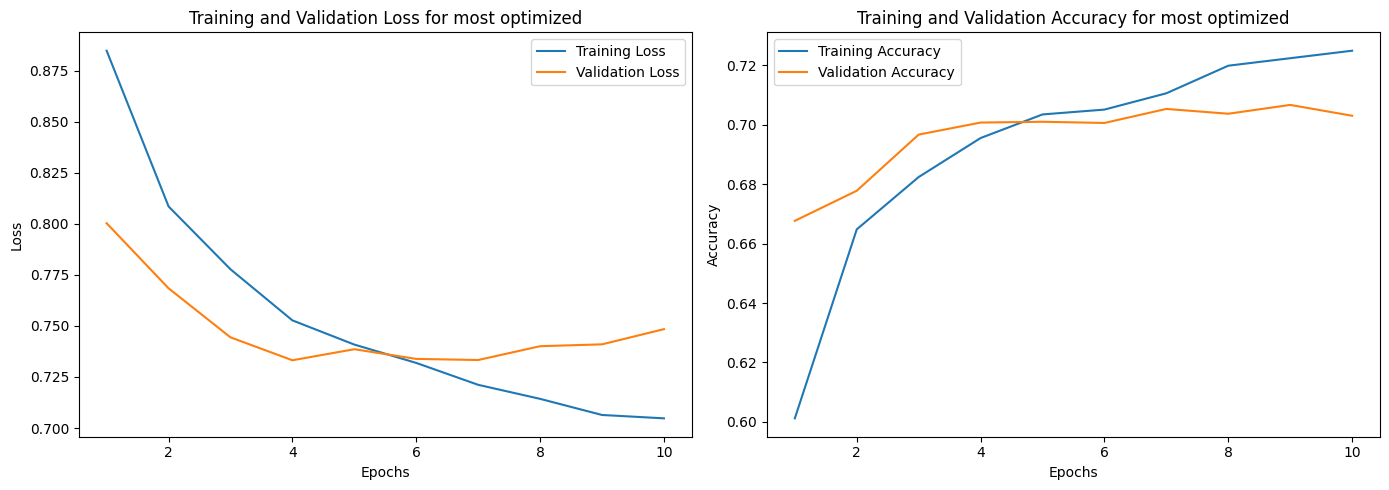

233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
### ------------------------------------------------------###


In [49]:
# Code cell
##Best configuration

regularizer = tf.keras.regularizers.l2(0.0001)
neural_mode_s2 = tf.keras.Sequential([
 InputLayer(shape=[462,]),
 Flatten(),
 Dropout(rate=0.1),
 Dense(48, activation='relu', kernel_regularizer=regularizer),
 Dropout(rate=0.1),
 Dense(24, activation='relu', kernel_regularizer=regularizer),
 Dropout(rate=0.1),
 Dense(12, activation='relu', kernel_regularizer=regularizer),
 Dropout(rate=0.1),
 Dense(6, activation='relu', kernel_regularizer=regularizer),
 Dropout(rate=0.1),
 Dense(3, activation='softmax')
])

neural_mode_s2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
neural_mode_s2.summary()
history_exp_const_nodes = neural_mode_s2.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_validation, y_validation))
plot_graph(history_exp_const_nodes, ' most optimized')
y_pred_neural = neural_mode_s2.predict(X_test)
print('### ------------------------------------------------------###')



        - Early stopping is a regularization technique in neural network training wherein the process is halted when validation set performance starts to decline, thus preventing overfitting by avoiding the learning of noise in the training data. From all the experiments conducted thus far, choose **one** configuration (the number of layers, number of nodes, activation function, L2 penalty, and dropout layers) that yielded the best performance. Use a graph of loss and accuracy to determine the optimal number of training iterations for this network. What is the optimal number of epochs for this network configuration and why?

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)                  │ (None, 462)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_25 (Dropout)                 │ (None, 462)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ (None, 48)                  │          22,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_26 (Dropout)                 │ (None, 48)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_34 (Dense)                     │ (None, 24)                  │           1,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_27 (Dropout)                 │ (None, 24)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_35 (Dense)                     │ (None, 12)                  │             300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_28 (Dropout)                 │ (None, 12)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_36 (Dense)                     │ (None, 6)                   │              78 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_29 (Dropout)                 │ (None, 6)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_37 (Dense)                     │ (None, 3)                   │              21 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,799 (92.96 KB)

 Trainable params: 23,799 (92.96 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.5046 - loss: 0.9850 - val_accuracy: 0.6674 - val_loss: 0.8097
Epoch 2/1000
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6521 - loss: 0.8277 - val_accuracy: 0.6803 - val_loss: 0.7832
Epoch 3/1000
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6756 - loss: 0.7913 - val_accuracy: 0.6911 - val_loss: 0.7655
Epoch 4/1000
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.6915 - loss: 0.7665 - val_accuracy: 0.7056 - val_loss: 0.7457
Epoch 5/1000
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6968 - loss: 0.7530 - val_accuracy: 0.7064 - val_loss: 0.7404
Epoch 6/1000
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.7083 - loss: 0.7349 - val_accuracy: 0.7046 - val_loss: 0.7441
Epoch 7/1000
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7150 - loss: 0.7176 - val_accuracy: 0.7098 - val_loss: 0.7300
Epoch 8/1000
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.71

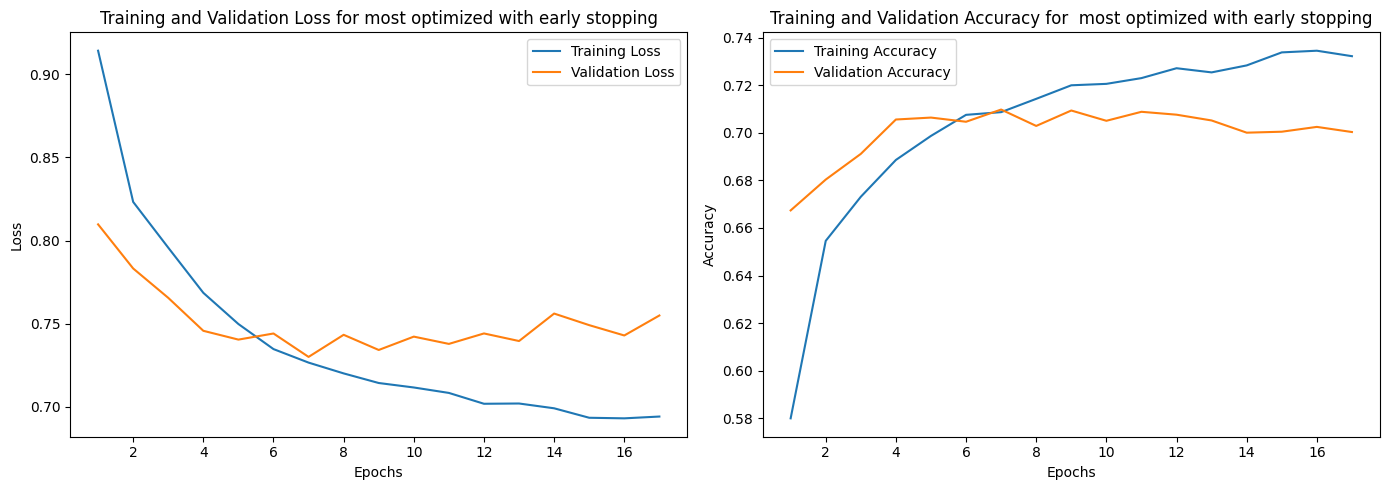

233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
### ------------------------------------------------------###


In [17]:
from keras.callbacks import EarlyStopping
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    patience=10,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0
)

regularizer = tf.keras.regularizers.l2(0.0001)
neural_mode_s2 = tf.keras.Sequential([
 InputLayer(shape=[462,]),
 Flatten(),
 Dropout(rate=0.1),
 Dense(48, activation='relu', kernel_regularizer=regularizer),
 Dropout(rate=0.1),
 Dense(24, activation='relu', kernel_regularizer=regularizer),
 Dropout(rate=0.1),
 Dense(12, activation='relu', kernel_regularizer=regularizer),
 Dropout(rate=0.1),
 Dense(6, activation='relu', kernel_regularizer=regularizer),
 Dropout(rate=0.1),
 Dense(3, activation='softmax')
])

neural_mode_s2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
neural_mode_s2.summary()
history_exp_const_nodes = neural_mode_s2.fit(X_train, y_train, epochs=1000, batch_size=32, validation_data=(X_validation, y_validation), callbacks = [callback])
plot_graph(history_exp_const_nodes, ' most optimized with early stopping')
y_pred_neural = neural_mode_s2.predict(X_test)
print('### ------------------------------------------------------###')

### Test

9. **Model Comparison**:

    - Evaluate the baseline model on the test set, using the optimal parameter set identified through grid search. Additionally, apply your best-performing neural network configuration to the test set.

    - Quantify the performance of the baseline model (best hyperparameter configuration) and your neural network (best configuration) using precision, recall, and F1-score as metrics. How do these two models compare to the dummy model?

    - Provide recommendations on which model(s) to choose for this task and justify your choices based on the analysis results.

- For the evaluation of the baseline model, we have picked the LogisticRegression model and used the optimised parameters as per the hyperparameter tuning step. From the training results we see a F1 score of 66%, however prediction score of the model is very low (33% F1 score). This type of model is not fit for prediction of this data set due to such low scores.

- Comparing the prediction accuracy, neural network has the highest score in all aspects, followed by the baseline model and the dummy model.

- The recommendation is to choose the neural network model due to better scores in the accuracy of the prediction.

In [32]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import make_scorer
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
#from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from scikeras.wrappers import KerasClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.dummy import DummyClassifier


dummy_model = DummyClassifier(strategy='most_frequent')
dummy_model.fit(X_train, y_train)
y_pred_dummy = dummy_model.predict(X_test)

cvKF = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_dummy_model = cross_validate(dummy_model, X_train, y_train, cv=cvKF, scoring=scoring)
print('\n### Test results metric for Cross Validation for Dummy model ###')
print("Precision:", np.mean(cv_scores_dummy_model['test_precision_macro']))
print("Recall:", np.mean(cv_scores_dummy_model['test_recall_macro']))
print("F1 Score:", np.mean(cv_scores_dummy_model['test_f1_macro']))

print('\n### Prediction results for Dummy model ###')

print('Accuracy:', accuracy_score(y_test, y_pred_dummy))
print('Precision Score:' , precision_score(y_test, y_pred_dummy,average = 'macro'))
print('Recall score:' , recall_score(y_test, y_pred_dummy, average = 'macro'))
print('F1 Score:' , f1_score(y_test, y_pred_dummy, average = 'macro'))







#baseline model (Logistic Regression)
cv_scores_logistic_model = cross_validate(logistic_model, X_train, y_train, cv=cvKF, scoring=scoring)
print('\n### Test results metric for Cross Validation for Baseline model (Logistic Regression) ###')
print("Precision:", np.mean(cv_scores_logistic_model['test_precision_macro']))
print("Recall:", np.mean(cv_scores_logistic_model['test_recall_macro']))
print("F1 Score:", np.mean(cv_scores_logistic_model['test_f1_macro']))


#BaseLine model(Logistic regression)
logistic_model_optimized = LogisticRegression( max_iter=800, penalty='l2', tol= 0.0001)
logistic_model_optimized.fit(X_train, y_train)
#cross validation for baseline model (Decision tree)
scoring = ['precision_macro', 'recall_macro','f1_macro']
#cross validation ensuring suffling
cvKF = KFold(n_splits=5, shuffle=True, random_state=42)
#baseline model (Logistic Regression)
cv_scores_logistic_model = cross_validate(logistic_model, X_train, y_train, cv=cvKF, scoring=scoring)
print('\n### Test results metric for Cross Validation for tuned Baseline model (Logistic Regression) ###')
print("Precision:", np.mean(cv_scores_logistic_model['test_precision_macro']))
print("Recall:", np.mean(cv_scores_logistic_model['test_recall_macro']))
print("F1 Score:", np.mean(cv_scores_logistic_model['test_f1_macro']))

print('\n### Prediction results for tuned Baseline model (Logistic Regression) ###')
LRC_y_pred_def = logistic_model_optimized.predict(X_test)
print('Accuracy:', accuracy_score(y_test, LRC_y_pred_def))
print('Precision Score:' , precision_score(y_test, LRC_y_pred_def,average = 'macro'))
print('Recall score:' , recall_score(y_test, LRC_y_pred_def, average = 'macro'))
print('F1 Score:' , f1_score(y_test, LRC_y_pred_def, average = 'macro'))








regularizer = tf.keras.regularizers.l2(0.0001)
neural_mode_s2 = tf.keras.Sequential([
 InputLayer(shape=[462,]),
 Flatten(),
 Dropout(rate=0.1),
 Dense(48, activation='relu', kernel_regularizer=regularizer),
 Dropout(rate=0.1),
 Dense(24, activation='relu', kernel_regularizer=regularizer),
 Dropout(rate=0.1),
 Dense(12, activation='relu', kernel_regularizer=regularizer),
 Dropout(rate=0.1),
 Dense(6, activation='relu', kernel_regularizer=regularizer),
 Dropout(rate=0.1),
 Dense(3, activation='softmax')
])

neural_mode_s2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
neural_mode_s2.summary()
history_exp_const_nodes = neural_mode_s2.fit(X_train, y_train, epochs=17, batch_size=32, validation_data=(X_validation, y_validation), verbose=1)
#plot_graph(history_exp_const_nodes, ' most optimized')





#cross validation for neural network
cvKF = KFold(n_splits=2, shuffle=True, random_state=42)
#keras model that has been used for neural model is not compatiblKerasClassifiere with cross vaidate as it expexts scikit estimator
neural_model_wrapped = KerasClassifier(build_fn=neural_mode_s2, epochs=17, batch_size=32, verbose=1)
cv_scores_neural_model = cross_validate(neural_model_wrapped, X_train, y_train, cv=cvKF, scoring=scoring)

print('\n### Test results metric for Cross Validation for optimized neural model ###')
print("Precision:", np.mean(cv_scores_neural_model['test_precision_macro']))
print("Recall:", np.mean(cv_scores_neural_model['test_recall_macro']))
print("F1 Score:", np.mean(cv_scores_neural_model['test_f1_macro']))

y_pred_neural = neural_mode_s2.predict(X_test).round()
y_pred_bool = np.argmax(y_pred_neural, axis=1)
print(classification_report(y_test, y_pred_bool))

print('\n### Prediction results for optimized neural model ###')
#print('Accuracy:', accuracy_score(y_test, y_pred_neural))
#print('Precision Score:' , precision_score(y_test, y_pred_neural,average = 'macro'))
#print('Recall score:' , recall_score(y_test, y_pred_neural, average = 'macro'))
#print('F1 Score:' , f1_score(y_test, y_pred_neural, average = 'macro'))




/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m


### Test results metric for Cross Validation for Dummy model ###
Precision: 0.13715903242408645
Recall: 0.3333333333333333
F1 Score: 0.19434676028204334

### Prediction results for Dummy model ###
Accuracy: 0.41057731126362534
Precision Score: 0.13685910375454177
Recall score: 0.3333333333333333
F1 Score: 0.19404693760732683

### Test results metric for Cross Validation for Baseline model (Logistic Regression) ###
Precision: 0.6782868800791191
Recall: 0.6602323822153763
F1 Score: 0.66627309892267

### Test results metric for Cross Validation for tuned Baseline model (Logistic Regression) ###
Precision: 0.6782868800791191
Recall: 0.6602323822153763
F1 Score: 0.66627309892267

### Prediction results for tuned Baseline model (Logistic Regression) ###
Accuracy: 0.3676490378145606
Precision Score: 0.3470640693139962
Recall score: 0.34501787129349576
F1 Score: 0.3393031206329134


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_13 (Flatten)                 │ (None, 462)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_65 (Dropout)                 │ (None, 462)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_73 (Dense)                     │ (None, 48)                  │          22,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_66 (Dropout)                 │ (None, 48)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_74 (Dense)                     │ (None, 24)                  │           1,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_67 (Dropout)                 │ (None, 24)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_75 (Dense)                     │ (None, 12)                  │             300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_68 (Dropout)                 │ (None, 12)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_76 (Dense)                     │ (None, 6)                   │              78 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_69 (Dropout)                 │ (None, 6)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_77 (Dense)                     │ (None, 3)                   │              21 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,799 (92.96 KB)

...

Epoch 1/17
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.5471 - loss: 0.9622 - val_accuracy: 0.6731 - val_loss: 0.7919
Epoch 2/17
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6634 - loss: 0.8139 - val_accuracy: 0.6830 - val_loss: 0.7746
Epoch 3/17
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6764 - loss: 0.7881 - val_accuracy: 0.6948 - val_loss: 0.7558
Epoch 4/17
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6954 - loss: 0.7608 - val_accuracy: 0.6986 - val_loss: 0.7508
Epoch 5/17
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7005 - loss: 0.7433 - val_accuracy: 0.7001 - val_loss: 0.7390
Epoch 6/17
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7091 - loss: 0.7296 - val_accuracy: 0.6986 - val_loss: 0.7377
Epoch 7/17
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7179 - loss: 0.7156 - val_accuracy: 0.7090 - val_loss: 0.7357
Epoch 8/17
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7241 - loss: 0.7087

/usr/local/lib/python3.10/dist-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


911/911 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7424 - loss: 0.6725
Epoch 2/17
911/911 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7483 - loss: 0.6619
Epoch 3/17
911/911 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7552 - loss: 0.6538
Epoch 4/17
911/911 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7611 - loss: 0.6435
Epoch 5/17
911/911 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7635 - loss: 0.6330
Epoch 6/17
911/911 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7641 - loss: 0.6348
Epoch 7/17
911/911 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7668 - loss: 0.6286
Epoch 8/17
911/911 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7759 - loss: 0.6188
Epoch 9/17
911/911 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7754 - loss: 0.6120
Epoch 10/17
911/911 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7753 - loss: 0.6138
Epoch 11/17
911/911 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7778 - loss: 0.6078
Epoch 12/17
911/911 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy

/usr/local/lib/python3.10/dist-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


911/911 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7456 - loss: 0.6706
Epoch 2/17
911/911 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7519 - loss: 0.6603
Epoch 3/17
911/911 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7602 - loss: 0.6413
Epoch 4/17
911/911 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7636 - loss: 0.6314
Epoch 5/17
911/911 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7637 - loss: 0.6332
Epoch 6/17
911/911 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7675 - loss: 0.6210
Epoch 7/17
911/911 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7725 - loss: 0.6194
Epoch 8/17
911/911 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7725 - loss: 0.6169
Epoch 9/17
911/911 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7768 - loss: 0.6051
Epoch 10/17
911/911 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7769 - loss: 0.6070
Epoch 11/17
911/911 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7816 - loss: 0.6064
Epoch 12/17
911/911 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy

# Resources


1.   https://machinelearningmastery.com/how-to-stop-training-deep-neural-networks-at-the-right-time-using-early-stopping/
2.   https://keras.io/api/callbacks/early_stopping/
3. https://egallic.fr/Enseignement/ML/ECB/book/deep-learning.html
4. https://adriangb.com/scikeras/stable/generated/scikeras.wrappers.KerasClassifier.html


